## SUPERVISED FAULT DETECTION USING GATED RECURRENT UNITS DEEP LEARNING MODELS

## INITIALIZATION

#### Loading Google Drive and Creating Directories

In [ ]:
# Loading the google colab package and mounting the google drive to google colab
from google.colab import drive

drive.mount('/content/drive')

# Create the log directory
!mkdir '/content/drive/MyDrive/logs'

# Create the models directory
!mkdir '/content/drive/MyDrive/models'

Mounted at /content/drive
mkdir: cannot create directory ‘/content/drive/MyDrive/logs’: File exists
mkdir: cannot create directory ‘/content/drive/MyDrive/models’: File exists


#### Installing Pre-requisite Packages

In [ ]:
!pip install tensorboardX ray scikeras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 MB 8.3 MB/s eta 0:00:00


#### Loading Requisite Packages to the Workspace

In [ ]:
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from statistics import mode
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Tensorflow
from tensorflow import keras
from tensorflow.keras.utils import normalize, to_categorical
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras.layers import BatchNormalization
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input, Dense, Activation, LSTM, GRU, SimpleRNN, Conv1D, TimeDistributed, MaxPooling1D, Flatten, Dropout
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameter
import ray
from ray import train, tune
from ray.tune.schedulers import AsyncHyperBandScheduler
from ray.air.integrations.keras import ReportCheckpointCallback

from tensorflow.keras.optimizers import Adam, RMSprop
from functools import partial
from ray.tune.schedulers import ASHAScheduler


# Setting the random seeds for reproductibility
np.random.seed(42)
random.seed(42)


##### Setting Seed For Random Number Generators and Loading the Data to Workspace

In [ ]:
# Importing the Data

delay_app = pd.read_csv('/content/drive/MyDrive/Data2/DelayAPP.csv')
gain_rpm = pd.read_csv('/content/drive/MyDrive/Data2/GainRPM.csv')
healthy_data = pd.read_csv('/content/drive/MyDrive/Data2/HealthyData.csv')
noise_app = pd.read_csv('/content/drive/MyDrive/Data2/NoiseAPP.csv')
packetLoss_app = pd.read_csv('/content/drive/MyDrive/Data2/PacketLossAPP.csv')

In [ ]:
print(Counter(delay_app['class']))
print(Counter(gain_rpm['class']))
print(Counter(noise_app['class']))
print(Counter(packetLoss_app['class']))

Counter({1: 4805, 0: 3615})
Counter({1: 6614, 0: 1806})
Counter({1: 5338, 0: 3082})
Counter({1: 6318, 0: 2102})


In [ ]:
#delay_app['Timestamp'] = healthy_data['Timestamp']
#gain_rpm['Timestamp'] = healthy_data['Timestamp']
#noise_app['Timestamp'] = healthy_data['Timestamp']
#packetLoss_app['Timestamp'] = healthy_data['Timestamp']

In [ ]:
#healthy_data = healthy_data.drop('Index', axis=1)
#gain_rpm = gain_rpm.drop('Index', axis=1)
#noise_app = noise_app.drop('Index', axis=1)
#packetLoss_app = packetLoss_app.drop('Index', axis=1)
#packetLoss_app

## Utility Functions

#### Turn the Time Series Data to Sequences

In [ ]:
def make_sequences(combined_data, test_size=0.2):
    features = combined_data.columns.tolist()
    features = [f for f in features if 'Sensor Reading' in f]
    dataframe = combined_data.copy()
    X_train_data = dataframe[features]
    y_train_data = dataframe['class']

    X_train_data = normalize(X_train_data, axis=1)

    sc = StandardScaler() # Standardization
    scaled_X_df = pd.DataFrame(sc.fit_transform(X_train_data))
    dataframe[features] = scaled_X_df
    df = dataframe
    cols = ['Timestamp']
    df[cols] = df[cols].applymap(np.int64)
    X_train = []
    y_train = []

    window_size = 20
    for b, group in df.groupby("Timestamp"):
      for d,e in group.groupby("class"):
        for i in range(len(e) - window_size + 1):
          temp = e[i: i + window_size]
          sequence_features = temp[features]
          X_train.append(sequence_features)
          y_train.append(d)


    #y_train_cat = to_categorical(y_train)

    X_train = np.array(X_train)
    X_train = X_train.reshape(-1, 20, 7)
    y_train_arr = np.array(y_train)

    X_train, X_test, y_train, y_test = train_test_split(X_train, y_train_arr, test_size=test_size, random_state=42)
    return X_train, X_test, y_train, y_test

In [ ]:
def make_sequences2(combined_data, test_size=0.2):
  features = combined_data.columns.tolist()
  features = [f for f in features if 'Sensor Reading' in f]
  X_train_data = combined_data[features]
  y_train_data = combined_data['class']

  X_train_data = normalize(X_train_data, axis=1)
  sc = StandardScaler()
  scaled_X_df = pd.DataFrame(sc.fit_transform(X_train_data))
  combined_data[features] = scaled_X_df

  df = combined_data
  cols = ['Timestamp']
  df[cols] = df[cols].applymap(np.int64)
  X_train = []
  y_train = []

  for b, group in df.groupby('Timestamp'):
    if len(group) == 20:
      temp = group
      seq_features = temp[features]
      X_train.append(seq_features)
      y_train.append(mode(temp['class']))
  X_train = np.array(X_train)
  #y_train_cat = to_categorical(y_train)
  y_train_cat = np.array(y_train)
  X_train, X_test, y_train, y_test = train_test_split(X_train, y_train_cat, test_size=test_size, random_state=42)
  return X_train, X_test, y_train, y_test


In [ ]:
def make_sequences3(combined_data, test_size=0.2):
  features = combined_data.columns.tolist()
  features = [f for f in features if 'Sensor Reading' in f]
  X_train_data = combined_data[features]
  y_train_data = combined_data['class']

  X_train_data = normalize(X_train_data, axis=1)
  sc = StandardScaler()
  scaled_X_df = pd.DataFrame(sc.fit_transform(X_train_data))
  combined_data[features] = scaled_X_df

  df = combined_data
  cols = ['Timestamp']
  df[cols] = df[cols].applymap(np.int64)
  X_train = []
  y_train = []

  for b, group in df.groupby('Timestamp'):
    if len(group) == 20:
      temp = group
      seq_features = temp[features]
      X_train.append(seq_features)
      counters_dict = dict(Counter(temp['class']))
      counters_dict[0] = counters_dict.get(0, 0)
      counters_dict[1] = counters_dict.get(1, 0)
      total_count = sum(counters_dict.values())
      percentages_list = [(count / total_count) for count in counters_dict.values()]
      y_train.append(percentages_list)
  X_train = np.array(X_train)
  #y_train_cat = to_categorical(y_train)
  y_train_cat = np.array(y_train)
  y_train_cat = y_train_cat[:,0].round(0)
  X_train, X_test, y_train, y_test = train_test_split(X_train, y_train_cat, test_size=test_size, random_state=42)
  return X_train, X_test, y_train, y_test

In [ ]:
def prep_data(dataframe, test_size=0.2):
  features = dataframe.columns.tolist()
  features = [f for f in features if 'Sensor Reading' in f]
  X_train_data = dataframe[features]
  y_train_data = dataframe['class']

  X_train_data = normalize(X_train_data, axis=1)
  sc = StandardScaler()
  scaled_X_df = pd.DataFrame(sc.fit_transform(X_train_data))
  dataframe[features] = scaled_X_df

  X_train = np.array(dataframe[features])
  y_train = np.array(to_categorical(y_train_data))

  X_train_reshaped = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))

  X_train, X_test, y_train, y_test = train_test_split(X_train_reshaped, y_train, test_size=test_size, random_state=42)

  return X_train, X_test, y_train, y_test

#### Function to Build the Model

In [ ]:
def build_model(num_classes, units=70, learning_rate=0.0001, momentum=0.95, optimizer='adam'):
    model = Sequential()
    import tensorflow as tf

    model.add(layers.GRU(units , return_sequences=True, activation='relu', input_shape=(20,7)))
    model.add(layers.GRU(units , return_sequences=True, activation='relu'))
    model.add(layers.GRU(units , return_sequences=True, activation='relu'))
    model.add(layers.GRU(units , return_sequences=False, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(Dense(num_classes, activation='sigmoid'))
    if optimizer == 'adam':
        opt= Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate, momentum=momentum)
    elif optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD(lr=learning_rate, momentum=momentum)
    model.compile(loss='binary_crossentropy',
                  optimizer= opt, metrics=['accuracy'])
    print('Model compiled!')
    print(model.summary())
    return model

#### Function to Performing Voting

In [ ]:
def single_fault_voter(y_true, predictions):
    threshold = 0.5
    pred = predictions.copy()
    preds = []
    for i in range(len(pred)):
        if max(pred[i]) == pred[i][0]:
            pred[i][0] = 1
            pred[i][1] = 0
            preds.append(1)
        elif max(pred[i] == pred[i][1]):
            pred[i][0] = 0
            pred[i][1] = 1
            preds.append(0)

    actual = []

    for i in range(len(y_true)):
        if max(y_true[i]) == y_true[i][0]:
            y_true[i][0] = 1
            y_true[i][1] = 0
            actual.append(1)
        elif max(pred[i] == pred[i][1]):
            pred[i][0] = 0
            pred[i][1] = 1
            actual.append(0)



    preds = np.array(preds)
    y_true = np.array(actual)
    return y_true, preds

In [ ]:
### THIS WILL NEED TO CHANGE!

def single_fault_voter2(y_true, predictions):
    threshold = 0.99
    pred = predictions.copy()
    binary_preds = (pred[:, 0] > threshold).astype(int)

    binary_preds = np.array(binary_preds)
    y_true = np.round(y_true[:, 0], 0)
    #y_true = y_true[:, 0]
    return y_true, binary_preds

#### Function to Plot the Confusion Matrix

In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)

    # Plot the confusion matrix as a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()


def generate_classificationReport(y_test, y_pred):
    report = classification_report(y_test, y_pred, zero_division=1)
    return report


#### Functions to Train the Model and Perform Hyperparameter Tuning

In [ ]:
def train_model(config, constant_params):
  import tensorflow as tf
  num_classes=2
  learning_rate = config['lr']
  units=config['units'] ## Should take data from config!!!

  X_train = constant_params['X_train']
  y_train = constant_params['y_train']

  model = Sequential()
  model.add(layers.GRU(units , return_sequences=True, activation='relu', input_shape=(20,7)))
  model.add(layers.GRU(units , return_sequences=True, activation='relu'))
  model.add(layers.GRU(units , return_sequences=True, activation='relu'))
  model.add(layers.GRU(units , return_sequences=False, activation='relu'))
  model.add(layers.BatchNormalization())
  model.add(Flatten())
  model.add(Dense(1, activation='sigmoid'))

  optimizer = config['optimizer']

  if optimizer == 'adam':
      opt= Adam(learning_rate=learning_rate)
  elif optimizer == 'rmsprop':
      opt = RMSprop(learning_rate=learning_rate)
  elif optimizer == 'sgd':
      opt = tf.keras.optimizers.SGD(lr=learning_rate, momentum=config['momentum'])

  model.compile(loss='binary_crossentropy',
                optimizer= opt, metrics=['accuracy'])
  print('Model compiled!')
  print(model.summary())
  model.fit(X_train, y_train, batch_size=config['batch_size'], epochs=config['epochs'], callbacks=[ReportCheckpointCallback(metrics = {'mean_accuracy': 'accuracy'})])

def tune_model(param_space, constant_params):
  num_samples = constant_params['num_samples']
  scheduler = AsyncHyperBandScheduler(
      time_attr = 'training_iteration', max_t=400, grace_period=1
  )

  scheduler = AsyncHyperBandScheduler(
      metric = 'mean_accuracy',
      mode = 'max',
      max_t=200,
      grace_period=1,
      reduction_factor=2,
  )

  result = tune.run(
      partial(train_model, constant_params=constant_params),
      resources_per_trial={'cpu':1, "gpu": 0},
      num_samples = num_samples,
      config=param_space,
      scheduler=scheduler,
  )

  print('Best model is:', result.get_best_trial('mean_accuracy','max','last').config)


#### Data Preparation

Delay APP

In [ ]:
if 'Index' in delay_app.columns:
  delay_app = delay_app.drop('Index', axis=1)

delayX_train, delayX_test, delayY_train, delayY_test = make_sequences2(delay_app)
delayY_train.shape

(322,)

#### Gain RPM

In [ ]:
if 'Index' in gain_rpm.columns:
  gain_rpm = gain_rpm.drop('Index', axis=1)

gainX_train, gainX_test, gainY_train, gainY_test = make_sequences2(gain_rpm)
gainX_train.shape


(333, 20, 7)

#### Noise APP

In [ ]:
if 'Index' in noise_app.columns:
  noise_app = noise_app.drop('Index', axis=1)

noiseX_train, noiseX_test, noiseY_train, noiseY_test = make_sequences2(noise_app)
noiseX_train.shape


(324, 20, 7)

#### PacketLoss APP

In [ ]:
if 'Index' in packetLoss_app.columns:
  packetLoss_app = packetLoss_app.drop('Index', axis=1)

packetLossX_train, packetLossX_test, packetLossY_train, packetLossY_test = make_sequences2(packetLoss_app)
packetLossX_train.shape


(324, 20, 7)

## DELAY GRU

In [ ]:
units=70
learning_rate=0.001
momentum=0.99
optimizer='adam'
num_classes=2

model = Sequential()
import tensorflow as tf

model.add(layers.GRU(units , return_sequences=True, activation='relu', input_shape=(20,7)))
model.add(layers.GRU(units , return_sequences=True, activation='relu'))
model.add(layers.GRU(units , return_sequences=True, activation='relu'))
model.add(layers.GRU(units , return_sequences=False, activation='relu'))
model.add(layers.BatchNormalization())
model.add(Dense(1, activation='sigmoid'))
if optimizer == 'adam':
    opt= Adam(learning_rate=learning_rate)
elif optimizer == 'rmsprop':
    opt = RMSprop(learning_rate=learning_rate, momentum=momentum)
elif optimizer == 'sgd':
    opt = tf.keras.optimizers.SGD(lr=learning_rate, momentum=momentum)
model.compile(loss='binary_crossentropy',
              optimizer= opt, metrics=['accuracy'])
print('Model compiled!')
print(model.summary())



model.fit(delayX_train, delayY_train, epochs=100, batch_size=10)
preds = model.predict(delayX_test)
preds

Model compiled!
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_12 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_13 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_14 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_15 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_3 (Bat  (None, 70)                280       
 chNormalization)                                                
                                                                 
 dense_3 (Dense)             (None, 1)                 71        
                                      

array([[9.9676806e-01],
       [1.7261165e-01],
       [9.2791325e-01],
       [2.1639256e-02],
       [9.4307452e-01],
       [9.9550045e-01],
       [8.5639298e-02],
       [9.9490547e-01],
       [9.9820119e-01],
       [9.9395114e-01],
       [9.9652928e-01],
       [1.6048547e-03],
       [1.4324749e-01],
       [9.9802136e-01],
       [7.9164602e-02],
       [1.0865697e-01],
       [3.3694536e-03],
       [2.0326008e-01],
       [4.8643941e-01],
       [9.9933970e-01],
       [3.1415290e-01],
       [9.9781084e-01],
       [9.9495238e-01],
       [1.7435011e-01],
       [9.8030812e-01],
       [9.9811590e-01],
       [7.5959172e-03],
       [3.4934163e-02],
       [9.9295717e-01],
       [5.0544733e-01],
       [1.2103490e-01],
       [4.6786303e-03],
       [9.6908969e-01],
       [7.3912805e-01],
       [1.3226059e-01],
       [9.9245381e-01],
       [9.9552208e-01],
       [5.3789973e-02],
       [5.5057746e-03],
       [8.3751595e-01],
       [9.9553162e-01],
       [9.988492

In [ ]:
model = delay_GRUmodel

In [ ]:
delayPreds = model.predict(delayX_test)
gainPreds = model.predict(gainX_test)
noisePreds = model.predict(noiseX_test)
packetLossPreds = model.predict(packetLossX_test)

3/3 [==============================] - 0s 13ms/step


In [ ]:
print(np.mean(delayPreds, axis=0))
print(np.mean(gainPreds, axis=0))
print(np.mean(noisePreds, axis=0))
print(np.mean(packetLossPreds, axis=0))

[0.53411394]
[0.71938914]
[0.7158222]
[0.69494957]


In [ ]:
pred = (delayPreds > 0.5).astype(int)
pred

array([[1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1]])

In [ ]:
accuracy_score(delayY_test, pred)

0.7654320987654321

In [ ]:
cce_preds = preds.copy()
cce_preds

array([[0.9936597 , 0.00634037],
       [0.9888359 , 0.01116415],
       [0.77569866, 0.2243013 ],
       [0.84015715, 0.15984288],
       [0.9968232 , 0.0031768 ],
       [0.9820534 , 0.01794645],
       [0.9878929 , 0.01210709],
       [0.9939984 , 0.0060016 ],
       [0.9877961 , 0.01220382],
       [0.9922212 , 0.00777887],
       [0.9871223 , 0.01287771],
       [0.99716467, 0.00283537],
       [0.99353117, 0.00646889],
       [0.9971668 , 0.00283322],
       [0.98790026, 0.01209969],
       [0.9968728 , 0.00312722],
       [0.996394  , 0.00360606],
       [0.9820205 , 0.01797934],
       [0.9868978 , 0.0131022 ],
       [0.9966654 , 0.00333459],
       [0.99359006, 0.00640997],
       [0.9938633 , 0.00613669],
       [0.98812747, 0.01187247],
       [0.9598851 , 0.04011489],
       [0.9989246 , 0.00107538],
       [0.99614346, 0.00385645],
       [0.9953733 , 0.00462655],
       [0.9963853 , 0.00361461],
       [0.9967677 , 0.00323226],
       [0.9867932 , 0.0132068 ],
       [0.

In [ ]:
dt = (delayY_test > 0.99).astype(int)
binary_preds

array([[1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1,

In [ ]:
#preds = np.round(preds,1)

y_true, y_pred = single_fault_voter(delayY_test, preds)
plot_confusion_matrix(y_true, y_pred, classes=2, title='CM')
report = generate_classificationReport(y_true, y_pred)
print(report)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

#### Delay-GRU Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning
params =  {
        'units': tune.choice([60, 70,80, 100]),
        'lr': tune.choice([0.0001,0.00001]),
        'batch_size': tune.choice([10, 20, 50]),
        'epochs': tune.choice([50,80,100]),
        'optimizer': tune.choice(['adam', 'rmsprop']),
        'momentum' : tune.choice([0.99,0.97,0.95])
        }

constant_params = {
    'X_train': delayX_train,
    'y_train': delayY_train,
    'num_samples': 40


}

tune_model(param_space=params, constant_params=constant_params)


2024-02-12 13:47:40,977	INFO tune.py:592 -- [output] This will use the new output engine with verbosity 2. To disable the new output and use the legacy output engine, set the environment variable RAY_AIR_NEW_OUTPUT=0. For more information, please see https://github.com/ray-project/ray/issues/36949


+--------------------------------------------------------------------+
| Configuration for experiment     train_model_2024-02-12_13-47-40   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        AsyncHyperBandScheduler           |
| Number of trials                 40                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_model_2024-02-12_13-47-40
To visualize your results with TensorBoard, run: `tensorboard --logdir /root/ray_results/train_model_2024-02-12_13-47-40`

Trial status: 16 PENDING
Current time: 2024-02-12 13:47:41. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+------------------------------------------------------------------------------------------------------------+
| Trial name                status       units       lr     batc

(pid=84017) 2024-02-12 13:47:47.159536: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=84017) 2024-02-12 13:47:47.159600: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=84017) 2024-02-12 13:47:47.163820: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=84046) 2024-02-12 13:47:49.518913: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



Trial train_model_4a67e_00001 started with configuration:
+-------------------------------------------------+
| Trial train_model_4a67e_00001 config            |
+-------------------------------------------------+
| batch_size                                   20 |
| epochs                                       80 |
| lr                                       0.0001 |
| momentum                                   0.95 |
| optimizer                                  adam |
| units                                        70 |
+-------------------------------------------------+

Trial train_model_4a67e_00000 started with configuration:
+--------------------------------------------------+
| Trial train_model_4a67e_00000 config             |
+--------------------------------------------------+
| batch_size                                    20 |
| epochs                                        50 |
| lr                                       0.00001 |
| momentum                                  

(func pid=84046) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-47-40/train_model_4a67e_00001_1_batch_size=20,epochs=80,lr=0.0001,momentum=0.9500,optimizer=adam,units=70_2024-02-12_13-47-41/checkpoint_000000)
(pid=84046) 2024-02-12 13:47:47.179309: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=84046) 2024-02-12 13:47:47.179361: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=84046) 2024-02-12 13:47:47.180471: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=84017) 2024-02-12 13:47:49.732732: W tensorflow/

...

(func pid=84046) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-47-40/train_model_4a67e_00036_36_batch_size=20,epochs=80,lr=0.0000,momentum=0.9500,optimizer=adam,units=100_2024-02-12_13-51-12/checkpoint_000000) [repeated 2x across cluster]


21/33 [==================>...........] - ETA: 0s - loss: 0.8160 - accuracy: 0.3619
(func pid=84046) Model compiled!
(func pid=84046) Model: "sequential"
(func pid=84046)  Layer (type)                Output Shape              Param #   
(func pid=84046)  gru (GRU)                   (None, 20, 60)            12420     
(func pid=84046)  batch_normalization (Batch  (None, 60)                240       
(func pid=84046)  Normalization)                                                  
(func pid=84046)  flatten (Flatten)           (None, 60)                0         
(func pid=84046)  dense (Dense)               (None, 1)                 61        
(func pid=84046) Total params: 78601 (307.04 KB)
(func pid=84046) Trainable params: 78481 (306.57 KB)
(func pid=84046) Non-trainable params: 120 (480.00 Byte)
(func pid=84046) None
32/33 [============================>.] - ETA: 0s - loss: 0.8096 - accuracy: 0.3781

Trial train_model_4a67e_00035 finished iteration 1 at 2024-02-12 13:53:45. Total run

(func pid=84046) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-47-40/train_model_4a67e_00037_37_batch_size=10,epochs=80,lr=0.0000,momentum=0.9700,optimizer=adam,units=60_2024-02-12_13-51-23/checkpoint_000000) [repeated 2x across cluster]


 8/33 [======>.......................] - ETA: 1s - loss: 0.6018 - accuracy: 0.7000

Trial train_model_4a67e_00038 finished iteration 1 at 2024-02-12 13:53:54. Total running time: 6min 13s
+------------------------------------------------------------+
| Trial train_model_4a67e_00038 result                       |
+------------------------------------------------------------+
| checkpoint_dir_name                      checkpoint_000000 |
| time_this_iter_s                                   8.94015 |
| time_total_s                                       8.94015 |
| training_iteration                                       1 |
| mean_accuracy                                       0.7757 |
+------------------------------------------------------------+
Trial train_model_4a67e_00038 saved a checkpoint for iteration 1 at: (local)/root/ray_results/train_model_2024-02-12_13-47-40/train_model_4a67e_00038_38_batch_size=10,epochs=100,lr=0.0000,momentum=0.9900,optimizer=rmsprop,units=100_2024-02-12_13

(func pid=84046) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-47-40/train_model_4a67e_00039_39_batch_size=20,epochs=80,lr=0.0000,momentum=0.9500,optimizer=rmsprop,units=70_2024-02-12_13-51-39/checkpoint_000000) [repeated 4x across cluster]


In [ ]:
delay_GRUmodel = build_model(num_classes=1, units=80, learning_rate=0.0001, momentum=0.99, optimizer='adam')
delay_GRUmodel.fit(delayX_train, delayY_train,batch_size=20, epochs=100)
#joblib.dump(delay_GRUmodel, '/content/drive/MyDrive/models/delayGRU_sigmoid002.pkl')

Model compiled!
Model: "sequential_42"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_168 (GRU)               (None, 20, 80)            21360     
                                                                 
 gru_169 (GRU)               (None, 20, 80)            38880     
                                                                 
 gru_170 (GRU)               (None, 20, 80)            38880     
                                                                 
 gru_171 (GRU)               (None, 80)                38880     
                                                                 
 batch_normalization_42 (Ba  (None, 80)                320       
 tchNormalization)                                               
                                                                 
 dense_42 (Dense)            (None, 1)                 81        
                                     

['/content/drive/MyDrive/models/delayGRU_sigmoid002.pkl']

##### Single Fault Detection Tests

##### Delay Data

Classification Report:
3/3 [==============================] - 0s 39ms/step
              precision    recall  f1-score   support

           0       0.30      0.21      0.25        34
           1       0.53      0.66      0.59        47

    accuracy                           0.47        81
   macro avg       0.42      0.43      0.42        81
weighted avg       0.44      0.47      0.45        81

Confusion Matrix:


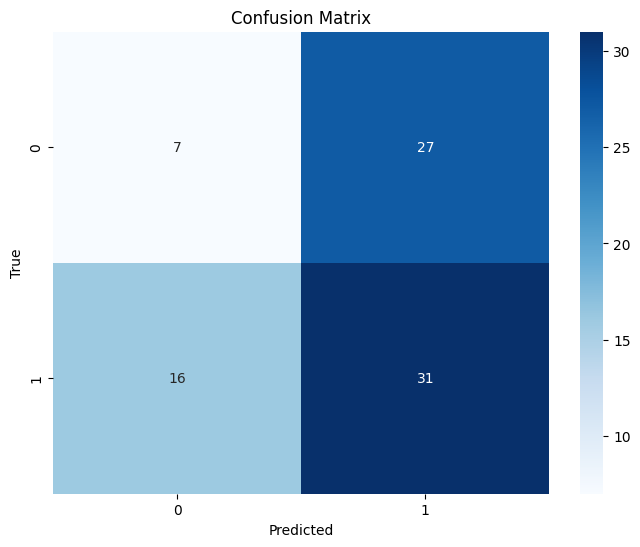

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(delayX_test)
threshold = 0.5 #np.mean(pred)
pred = (pred > threshold).astype(int)
#y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(delayY_test, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(delayY_test, pred, classes=[0,1], title='Confusion Matrix')

##### Gain Data

Classification Report:
3/3 [==============================] - 0s 16ms/step
              precision    recall  f1-score   support

           0       1.00      0.11      0.19        19
           1       0.79      1.00      0.88        64

    accuracy                           0.80        83
   macro avg       0.90      0.55      0.54        83
weighted avg       0.84      0.80      0.72        83

Confusion Matrix:


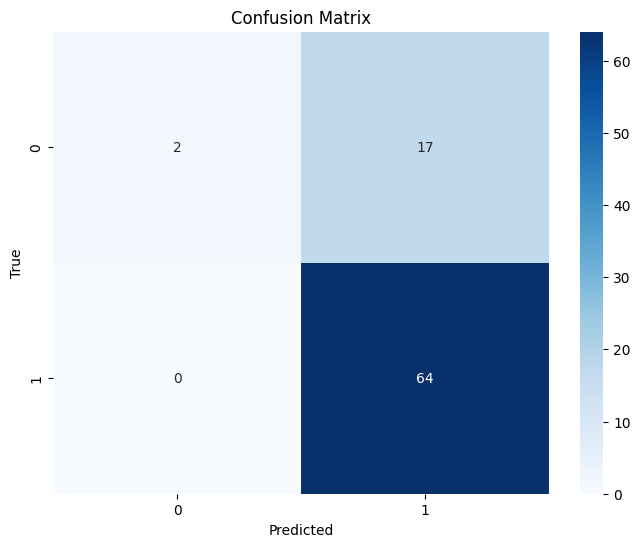

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(gainX_test)
#y_true, pred= single_fault_voter(gainY_test, pred)
pred = (pred > threshold).astype(int)
report = generate_classificationReport(gainY_test, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(gainY_test, pred, classes=[0,1], title='Confusion Matrix')

#### Noise Data

Classification Report:
3/3 [==============================] - 0s 14ms/step
              precision    recall  f1-score   support

           0       0.70      0.50      0.58        28
           1       0.77      0.89      0.83        54

    accuracy                           0.76        82
   macro avg       0.74      0.69      0.71        82
weighted avg       0.75      0.76      0.74        82

Confusion Matrix:


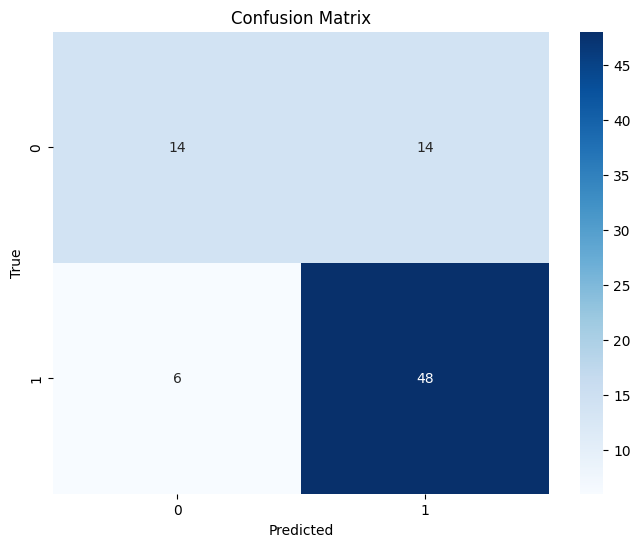

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(noiseX_test)
#y_true, pred= single_fault_voter(noiseY_test, pred)
pred = (pred > threshold).astype(int)
report = generate_classificationReport(noiseY_test, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(noiseY_test, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
3/3 [==============================] - 0s 16ms/step
              precision    recall  f1-score   support

           0       0.33      0.17      0.22        24
           1       0.72      0.86      0.78        59

    accuracy                           0.66        83
   macro avg       0.53      0.52      0.50        83
weighted avg       0.61      0.66      0.62        83

Confusion Matrix:


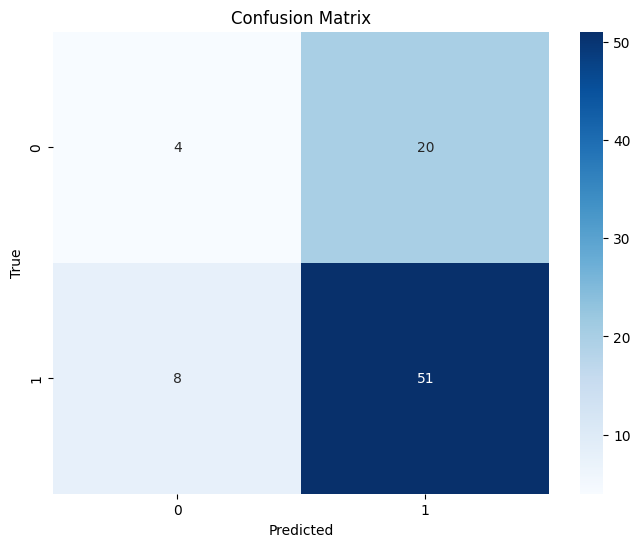

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(packetLossX_test)
#y_true, pred= single_fault_voter(packetLossY_test, pred)
pred = (pred > threshold).astype(int)
report = generate_classificationReport(packetLossY_test, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(packetLossY_test, pred, classes=[0,1], title='Confusion Matrix')

## GAIN RPM Model

#### GainRPM-GRU Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning
params =  {
        'units': tune.choice([60, 70,80, 100]),
        'lr': tune.choice([0.0001,0.00001]),
        'batch_size': tune.choice([10, 20, 50]),
        'epochs': tune.choice([50,80,100]),
        'optimizer': tune.choice(['adam', 'rmsprop']),
        'momentum' : tune.choice([0.99,0.97,0.95])
        }

constant_params = {
    'X_train': gainX_train,
    'y_train': gainY_train,
    'num_samples': 40


}

tune_model(param_space=params, constant_params=constant_params)

2024-02-12 13:16:28,042	INFO tune.py:592 -- [output] This will use the new output engine with verbosity 2. To disable the new output and use the legacy output engine, set the environment variable RAY_AIR_NEW_OUTPUT=0. For more information, please see https://github.com/ray-project/ray/issues/36949


+--------------------------------------------------------------------+
| Configuration for experiment     train_model_2024-02-12_13-16-28   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        AsyncHyperBandScheduler           |
| Number of trials                 40                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_model_2024-02-12_13-16-28
To visualize your results with TensorBoard, run: `tensorboard --logdir /root/ray_results/train_model_2024-02-12_13-16-28`

Trial status: 16 PENDING
Current time: 2024-02-12 13:16:28. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+------------------------------------------------------------------------------------------------------------+
| Trial name                status       units       lr     batc

(pid=74987) 2024-02-12 13:16:34.058806: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=74987) 2024-02-12 13:16:34.058868: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=74987) 2024-02-12 13:16:34.062084: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=74987) 2024-02-12 13:16:36.668690: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



Trial train_model_ee0c8_00000 started with configuration:
+-------------------------------------------------+
| Trial train_model_ee0c8_00000 config            |
+-------------------------------------------------+
| batch_size                                   10 |
| epochs                                       80 |
| lr                                       0.0001 |
| momentum                                   0.99 |
| optimizer                                  adam |
| units                                        80 |
+-------------------------------------------------+

Trial train_model_ee0c8_00001 started with configuration:
+--------------------------------------------------+
| Trial train_model_ee0c8_00001 config             |
+--------------------------------------------------+
| batch_size                                    50 |
| epochs                                        80 |
| lr                                        0.0001 |
| momentum                                  

(func pid=74989) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-16-28/train_model_ee0c8_00001_1_batch_size=50,epochs=80,lr=0.0001,momentum=0.9500,optimizer=rmsprop,units=100_2024-02-12_13-16-28/checkpoint_000000)
(pid=74989) 2024-02-12 13:16:34.080599: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=74989) 2024-02-12 13:16:34.080676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=74989) 2024-02-12 13:16:34.081890: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=74989) 2024-02-12 13:16:36.642784: W tensorf

...

(func pid=74987) Model compiled!
(func pid=74987) Model: "sequential"
(func pid=74987)  Layer (type)                Output Shape              Param #   
(func pid=74987)  gru (GRU)                   (None, 20, 80)            21360     
(func pid=74987)  batch_normalization (Batch  (None, 80)                320       
(func pid=74987)  Normalization)                                                  
(func pid=74987)  flatten (Flatten)           (None, 80)                0         
(func pid=74987)  dense (Dense)               (None, 1)                 81        
(func pid=74987) Total params: 138401 (540.63 KB)
(func pid=74987) Trainable params: 138241 (540.00 KB)
(func pid=74987) Non-trainable params: 160 (640.00 Byte)
(func pid=74987) None
16/17 [===========================>..] - ETA: 0s - loss: 0.6957 - accuracy: 0.5531

Trial train_model_ee0c8_00035 finished iteration 1 at 2024-02-12 13:20:51. Total running time: 4min 22s
+------------------------------------------------------------

(func pid=74987) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-16-28/train_model_ee0c8_00036_36_batch_size=50,epochs=100,lr=0.0001,momentum=0.9700,optimizer=rmsprop,units=80_2024-02-12_13-19-10/checkpoint_000000) [repeated 2x across cluster]


(func pid=74987) Model compiled!
(func pid=74987) Model: "sequential"
(func pid=74987)  Layer (type)                Output Shape              Param #   
(func pid=74987)  gru (GRU)                   (None, 20, 80)            21360     
(func pid=74987)  batch_normalization (Batch  (None, 80)                320       
(func pid=74987)  Normalization)                                                  
(func pid=74987)  flatten (Flatten)           (None, 80)                0         
(func pid=74987)  dense (Dense)               (None, 1)                 81        
(func pid=74987) Total params: 138401 (540.63 KB)
(func pid=74987) Trainable params: 138241 (540.00 KB)
(func pid=74987) Non-trainable params: 160 (640.00 Byte)
(func pid=74987) None
16/33 [=============>................] - ETA: 1s - loss: 0.7196 - accuracy: 0.3938

Trial status: 37 TERMINATED | 2 RUNNING | 1 PENDING
Current time: 2024-02-12 13:20:58. Total running time: 4min 30s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
+---

(func pid=74987) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-16-28/train_model_ee0c8_00038_38_batch_size=50,epochs=80,lr=0.0001,momentum=0.9900,optimizer=adam,units=80_2024-02-12_13-19-18/checkpoint_000000) [repeated 2x across cluster]


33/33 [==============================] - ETA: 0s - loss: 0.7359 - accuracy: 0.3891

Trial train_model_ee0c8_00039 finished iteration 1 at 2024-02-12 13:21:07. Total running time: 4min 39s
+------------------------------------------------------------+
| Trial train_model_ee0c8_00039 result                       |
+------------------------------------------------------------+
| checkpoint_dir_name                      checkpoint_000000 |
| time_this_iter_s                                   7.78977 |
| time_total_s                                       7.78977 |
| training_iteration                                       1 |
| mean_accuracy                                      0.38906 |
+------------------------------------------------------------+
Trial train_model_ee0c8_00039 saved a checkpoint for iteration 1 at: (local)/root/ray_results/train_model_2024-02-12_13-16-28/train_model_ee0c8_00039_39_batch_size=10,epochs=80,lr=0.0000,momentum=0.9700,optimizer=adam,units=80_2024-02-12_13-19-2

In [ ]:
gain_GRUmodel = build_model(num_classes=1,units=100, learning_rate=0.0001, momentum=0.95, optimizer='rmsprop')
gain_GRUmodel.fit(gainX_train, gainY_train,batch_size=50, epochs=80)
joblib.dump(gain_GRUmodel, '/content/drive/MyDrive/models/gainGRU_sigmoid002.pkl')

Model compiled!
Model: "sequential_38"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_152 (GRU)               (None, 20, 100)           32700     
                                                                 
 gru_153 (GRU)               (None, 20, 100)           60600     
                                                                 
 gru_154 (GRU)               (None, 20, 100)           60600     
                                                                 
 gru_155 (GRU)               (None, 100)               60600     
                                                                 
 batch_normalization_38 (Ba  (None, 100)               400       
 tchNormalization)                                               
                                                                 
 dense_38 (Dense)            (None, 1)                 101       
                                     

['/content/drive/MyDrive/models/gainGRU_sigmoid002.pkl']

#### Single Fault Classification Tests

#### Single Fault Detections Tests

##### Gain Data

Classification Report:
3/3 [==============================] - 0s 11ms/step
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.98      0.99        64

    accuracy                           0.99        83
   macro avg       0.97      0.99      0.98        83
weighted avg       0.99      0.99      0.99        83

Confusion Matrix:


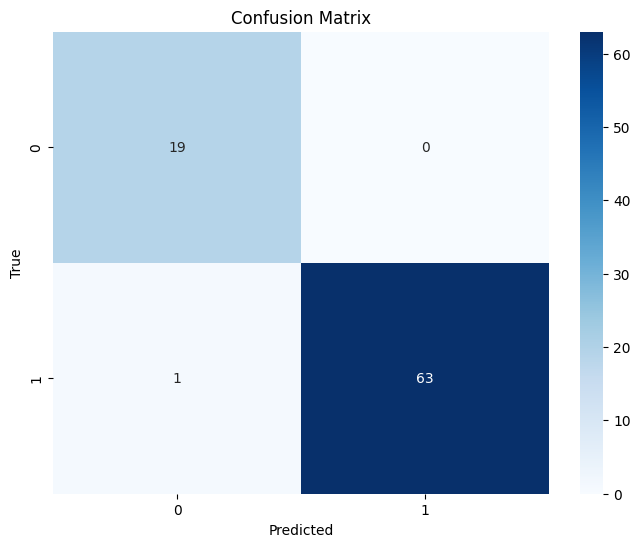

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(gainX_test)
#y_true, pred= single_fault_voter(gainY_test, pred)
threshold = np.mean(pred)
y_true = gainY_test.copy()
pred = (pred > threshold).astype(int)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Noise Data

Classification Report:
3/3 [==============================] - 0s 10ms/step
              precision    recall  f1-score   support

           0       0.83      0.18      0.29        28
           1       0.70      0.98      0.82        54

    accuracy                           0.71        82
   macro avg       0.77      0.58      0.55        82
weighted avg       0.74      0.71      0.64        82

Confusion Matrix:


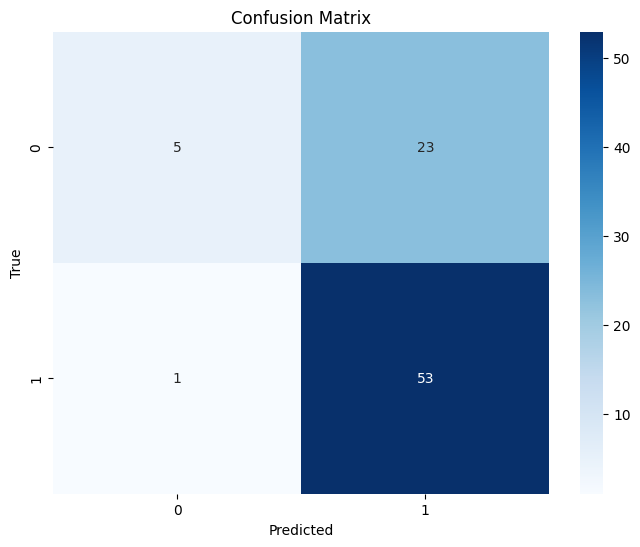

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(noiseX_test)
#y_true, pred= single_fault_voter(noiseY_test, pred)
y_true = noiseY_test.copy()
pred = (pred > threshold).astype(int)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
3/3 [==============================] - 0s 10ms/step
              precision    recall  f1-score   support

           0       0.58      0.32      0.42        34
           1       0.63      0.83      0.72        47

    accuracy                           0.62        81
   macro avg       0.60      0.58      0.57        81
weighted avg       0.61      0.62      0.59        81

Confusion Matrix:


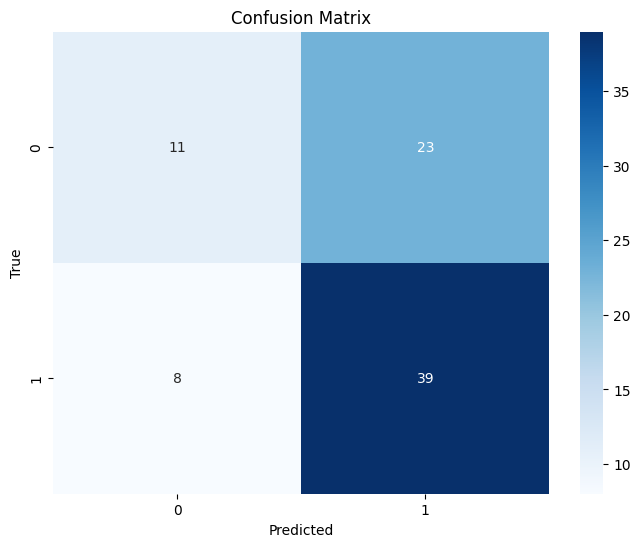

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(delayX_test)
#y_true, pred= single_fault_voter(delayY_test, pred)
y_true = delayY_test.copy()
pred = (pred > threshold).astype(int)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
3/3 [==============================] - 0s 12ms/step
              precision    recall  f1-score   support

           0       0.50      0.38      0.43        24
           1       0.77      0.85      0.81        59

    accuracy                           0.71        83
   macro avg       0.63      0.61      0.62        83
weighted avg       0.69      0.71      0.70        83

Confusion Matrix:


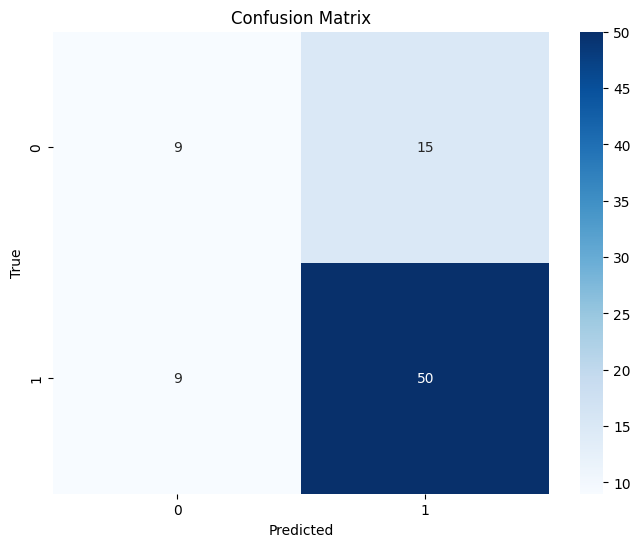

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(packetLossX_test)
#y_true, pred= single_fault_voter(packetLossY_test, pred)
y_true = packetLossY_test.copy()
pred = (pred > threshold).astype(int)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## NOISE APP model

#### Noise APP Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning
params =  {
        'units': tune.choice([60, 70,80, 100]),
        'lr': tune.choice([0.001,0.0001]),
        'batch_size': tune.choice([10, 20, 50]),
        'epochs': tune.choice([50, 80, 100]),
        'optimizer': tune.choice(['adam', 'rmsprop']),
        'momentum' : tune.choice([0.99,0.97,0.95])
        }

constant_params = {
    'X_train': noiseX_train,
    'y_train': noiseY_train,
    'num_samples': 20


}

tune_model(param_space=params, constant_params=constant_params)


2024-02-12 13:27:59,064	INFO tune.py:592 -- [output] This will use the new output engine with verbosity 2. To disable the new output and use the legacy output engine, set the environment variable RAY_AIR_NEW_OUTPUT=0. For more information, please see https://github.com/ray-project/ray/issues/36949


+--------------------------------------------------------------------+
| Configuration for experiment     train_model_2024-02-12_13-27-59   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        AsyncHyperBandScheduler           |
| Number of trials                 20                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_model_2024-02-12_13-27-59
To visualize your results with TensorBoard, run: `tensorboard --logdir /root/ray_results/train_model_2024-02-12_13-27-59`

Trial status: 16 PENDING
Current time: 2024-02-12 13:27:59. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+------------------------------------------------------------------------------------------------------------+
| Trial name                status       units       lr     batc

(pid=78313) 2024-02-12 13:28:02.676854: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=78313) 2024-02-12 13:28:02.676916: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=78313) 2024-02-12 13:28:02.678237: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=78313) 2024-02-12 13:28:04.820700: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



Trial train_model_89ee3_00000 started with configuration:
+--------------------------------------------------+
| Trial train_model_89ee3_00000 config             |
+--------------------------------------------------+
| batch_size                                    20 |
| epochs                                       100 |
| lr                                        0.0001 |
| momentum                                    0.99 |
| optimizer                                rmsprop |
| units                                        100 |
+--------------------------------------------------+

Trial train_model_89ee3_00001 started with configuration:
+-------------------------------------------------+
| Trial train_model_89ee3_00001 config            |
+-------------------------------------------------+
| batch_size                                   50 |
| epochs                                      100 |
| lr                                       0.0001 |
| momentum                              

(func pid=78313) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-27-59/train_model_89ee3_00000_0_batch_size=20,epochs=100,lr=0.0001,momentum=0.9900,optimizer=rmsprop,units=100_2024-02-12_13-27-59/checkpoint_000000)
(pid=78338) 2024-02-12 13:28:03.107468: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=78338) 2024-02-12 13:28:03.107530: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=78338) 2024-02-12 13:28:03.108668: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=78338) 2024-02-12 13:28:05.466657: W tensor

...

(func pid=78338) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-27-59/train_model_89ee3_00016_16_batch_size=20,epochs=100,lr=0.0001,momentum=0.9700,optimizer=rmsprop,units=70_2024-02-12_13-28-07/checkpoint_000000) [repeated 5x across cluster]


(func pid=78338) Model compiled!
(func pid=78338) Model: "sequential"
(func pid=78338) _________________________________________________________________
(func pid=78338)  Layer (type)                Output Shape              Param #   
(func pid=78338) =================================================================
(func pid=78338)  gru (GRU)                   (None, 20, 100)           32700     
(func pid=78338)                                                                  
(func pid=78338)  gru_1 (GRU)                 (None, 20, 100)           60600     
(func pid=78338)                                                                  
(func pid=78338)  gru_2 (GRU)                 (None, 20, 100)           60600     
(func pid=78338)                                                                  
(func pid=78338)  gru_3 (GRU)                 (None, 100)               60600     
(func pid=78338)                                                                  
(func pid=78338) 

(func pid=78338) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-27-59/train_model_89ee3_00018_18_batch_size=10,epochs=50,lr=0.0010,momentum=0.9500,optimizer=adam,units=100_2024-02-12_13-28-15/checkpoint_000000) [repeated 2x across cluster]


33/33 [==============================] - 9s 62ms/step - loss: 0.3064 - accuracy: 0.9012
(func pid=78338) Epoch 2/50
31/33 [===========================>..] - ETA: 0s - loss: 0.2694 - accuracy: 0.9161

Trial train_model_89ee3_00018 finished iteration 2 at 2024-02-12 13:32:03. Total running time: 4min 4s
+------------------------------------------------------------+
| Trial train_model_89ee3_00018 result                       |
+------------------------------------------------------------+
| checkpoint_dir_name                      checkpoint_000001 |
| time_this_iter_s                                   2.56549 |
| time_total_s                                      12.20323 |
| training_iteration                                       2 |
| mean_accuracy                                      0.91667 |
+------------------------------------------------------------+
Trial train_model_89ee3_00018 saved a checkpoint for iteration 2 at: (local)/root/ray_results/train_model_2024-02-12_13-27-59/trai

(func pid=78338) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-27-59/train_model_89ee3_00018_18_batch_size=10,epochs=50,lr=0.0010,momentum=0.9500,optimizer=adam,units=100_2024-02-12_13-28-15/checkpoint_000003) [repeated 5x across cluster]


In [ ]:
!export RAY_memory_monitor_refresh_ms=0

In [ ]:
noise_GRUmodel = build_model(num_classes=1,units=100, learning_rate=0.0001, momentum=0.99, optimizer='rmsprop')
noise_GRUmodel.fit(noiseX_train, noiseY_train,batch_size=20, epochs=100)
joblib.dump(noise_GRUmodel, '/content/drive/MyDrive/models/noiseGRU_sigma002.pkl')

Model compiled!
Model: "sequential_40"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_160 (GRU)               (None, 20, 100)           32700     
                                                                 
 gru_161 (GRU)               (None, 20, 100)           60600     
                                                                 
 gru_162 (GRU)               (None, 20, 100)           60600     
                                                                 
 gru_163 (GRU)               (None, 100)               60600     
                                                                 
 batch_normalization_40 (Ba  (None, 100)               400       
 tchNormalization)                                               
                                                                 
 dense_40 (Dense)            (None, 1)                 101       
                                     

['/content/drive/MyDrive/models/noiseGRU_sigma002.pkl']

In [ ]:
import gc

gc.collect()

1356

#### Single Fault Detections Tests

##### Noise Data

Classification Report:
3/3 [==============================] - 0s 11ms/step
              precision    recall  f1-score   support

           0       0.84      0.96      0.90        28
           1       0.98      0.91      0.94        54

    accuracy                           0.93        82
   macro avg       0.91      0.94      0.92        82
weighted avg       0.93      0.93      0.93        82

Confusion Matrix:


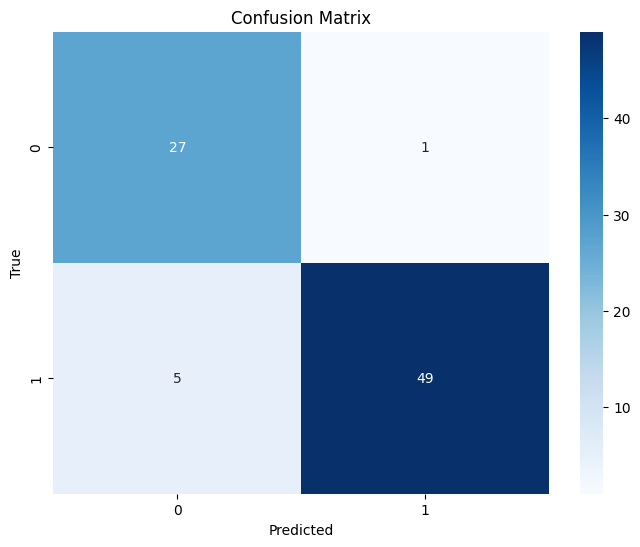

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(noiseX_test)
threshold = np.mean(pred)
pred = (pred > threshold).astype(int)
#y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(noiseY_test, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(noiseY_test, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
3/3 [==============================] - 0s 17ms/step
              precision    recall  f1-score   support

           0       0.56      0.85      0.67        34
           1       0.83      0.51      0.63        47

    accuracy                           0.65        81
   macro avg       0.69      0.68      0.65        81
weighted avg       0.71      0.65      0.65        81

Confusion Matrix:


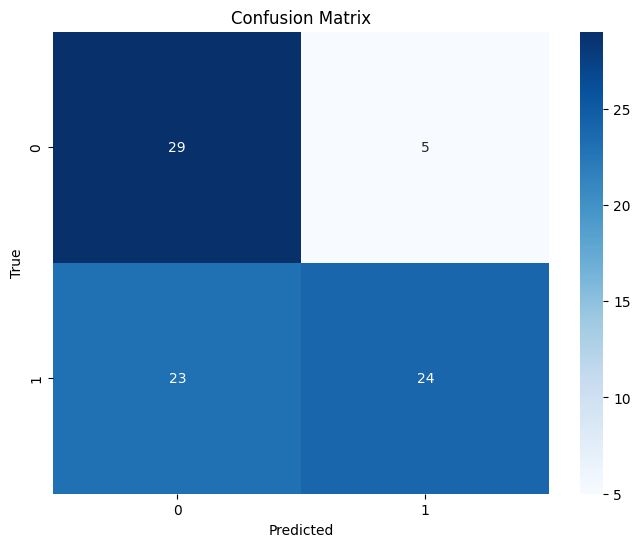

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(delayX_test)
#y_true, pred= single_fault_voter(delayY_test, pred)
y_true = delayY_test.copy()
pred = (pred > threshold).astype(int)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

#### Gain Data

Classification Report:
3/3 [==============================] - 0s 12ms/step
              precision    recall  f1-score   support

           0       0.33      0.95      0.49        19
           1       0.96      0.42      0.59        64

    accuracy                           0.54        83
   macro avg       0.65      0.68      0.54        83
weighted avg       0.82      0.54      0.56        83

Confusion Matrix:


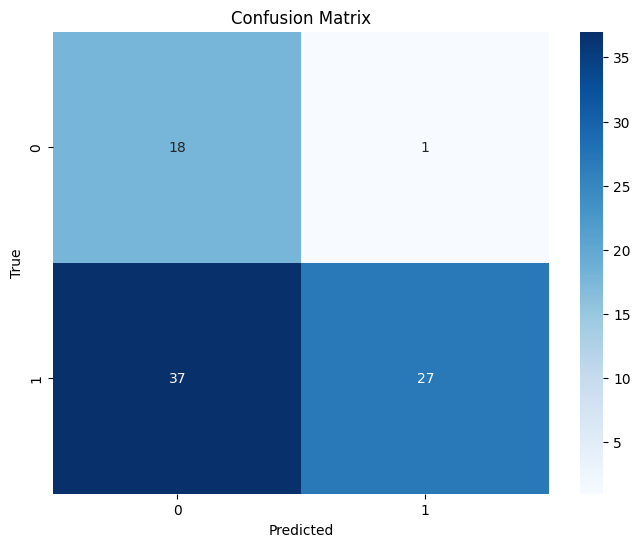

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(gainX_test)
#y_true, pred= single_fault_voter(gainY_test, pred)
y_true = gainY_test
pred = (pred > threshold).astype(int)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
3/3 [==============================] - 0s 13ms/step
              precision    recall  f1-score   support

           0       0.59      0.79      0.68        24
           1       0.90      0.78      0.84        59

    accuracy                           0.78        83
   macro avg       0.75      0.79      0.76        83
weighted avg       0.81      0.78      0.79        83

Confusion Matrix:


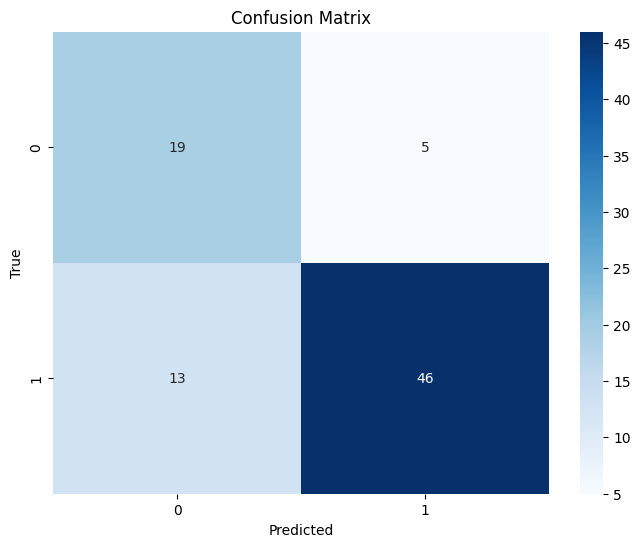

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(packetLossX_test)
#y_true, pred= single_fault_voter(packetLossY_test, pred)
y_true = packetLossY_test
pred = (pred > threshold).astype(int)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## PACKETLOSS APP model

#### PacketLossAPP-GRU Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning
params =  {

        'units': tune.choice([60, 70, 100]),
        'lr': tune.choice([0.0001,0.00001]),
        'batch_size': tune.choice([10, 20, 50]),
        'epochs': tune.choice([50, 80, 100]),
        'optimizer': tune.choice(['adam', 'rmsprop']),
        'momentum' : tune.choice([0.99,0.97,0.95]),
        }


constant_params = {
   'X_train': packetLossX_train,
   'y_train': packetLossY_train,
   'num_samples': 40
}

tune_model(params, constant_params)




2024-02-12 13:35:56,282	INFO tune.py:592 -- [output] This will use the new output engine with verbosity 2. To disable the new output and use the legacy output engine, set the environment variable RAY_AIR_NEW_OUTPUT=0. For more information, please see https://github.com/ray-project/ray/issues/36949


+--------------------------------------------------------------------+
| Configuration for experiment     train_model_2024-02-12_13-35-56   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        AsyncHyperBandScheduler           |
| Number of trials                 40                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_model_2024-02-12_13-35-56
To visualize your results with TensorBoard, run: `tensorboard --logdir /root/ray_results/train_model_2024-02-12_13-35-56`

Trial status: 16 PENDING
Current time: 2024-02-12 13:35:56. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+------------------------------------------------------------------------------------------------------------+
| Trial name                status       units       lr     batc

(pid=80617) 2024-02-12 13:35:59.840733: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=80617) 2024-02-12 13:35:59.840788: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=80617) 2024-02-12 13:35:59.842090: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=80617) 2024-02-12 13:36:01.490473: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



Trial train_model_a65f9_00000 started with configuration:
+--------------------------------------------------+
| Trial train_model_a65f9_00000 config             |
+--------------------------------------------------+
| batch_size                                    50 |
| epochs                                        80 |
| lr                                       0.00001 |
| momentum                                    0.95 |
| optimizer                                   adam |
| units                                         60 |
+--------------------------------------------------+

Trial train_model_a65f9_00001 started with configuration:
+--------------------------------------------------+
| Trial train_model_a65f9_00001 config             |
+--------------------------------------------------+
| batch_size                                    10 |
| epochs                                        50 |
| lr                                        0.0001 |
| momentum                        

(func pid=80617) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-35-56/train_model_a65f9_00000_0_batch_size=50,epochs=80,lr=0.0000,momentum=0.9500,optimizer=adam,units=60_2024-02-12_13-35-56/checkpoint_000000)
(pid=80635) 2024-02-12 13:36:00.297513: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=80635) 2024-02-12 13:36:00.297576: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=80635) 2024-02-12 13:36:00.298801: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=80635) 2024-02-12 13:36:01.933589: W tensorflow/

...

(func pid=80617) Model compiled!
(func pid=80617) Model: "sequential"
(func pid=80617)  Layer (type)                Output Shape              Param #   
(func pid=80617)  gru (GRU)                   (None, 20, 60)            12420     
(func pid=80617)  batch_normalization (Batch  (None, 60)                240       
(func pid=80617)  Normalization)                                                  
(func pid=80617)  flatten (Flatten)           (None, 60)                0         
(func pid=80617)  dense (Dense)               (None, 1)                 61        
(func pid=80617) Total params: 78601 (307.04 KB)
(func pid=80617) Trainable params: 78481 (306.57 KB)
(func pid=80617) Non-trainable params: 120 (480.00 Byte)
(func pid=80617) None
(func pid=80617) Epoch 1/100
6/7 [========================>.....] - ETA: 0s - loss: 0.6642 - accuracy: 0.6000

Trial train_model_a65f9_00035 finished iteration 1 at 2024-02-12 13:42:52. Total running time: 6min 56s
+-----------------------------------

(func pid=80617) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-35-56/train_model_a65f9_00036_36_batch_size=20,epochs=100,lr=0.0000,momentum=0.9500,optimizer=rmsprop,units=60_2024-02-12_13-39-46/checkpoint_000000) [repeated 3x across cluster]


(func pid=80617) Model compiled!
(func pid=80617) Model: "sequential"
(func pid=80617)  Layer (type)                Output Shape              Param #   
(func pid=80617)  gru (GRU)                   (None, 20, 70)            16590     
(func pid=80617)  batch_normalization (Batch  (None, 70)                280       
(func pid=80617)  Normalization)                                                  
(func pid=80617)  flatten (Flatten)           (None, 70)                0         
(func pid=80617)  dense (Dense)               (None, 1)                 71        
(func pid=80617) Total params: 106401 (415.63 KB)
(func pid=80617) Trainable params: 106261 (415.08 KB)
(func pid=80617) Non-trainable params: 140 (560.00 Byte)
(func pid=80617) None
7/7 [==============================] - ETA: 0s - loss: 0.6405 - accuracy: 0.6344

Trial train_model_a65f9_00037 finished iteration 1 at 2024-02-12 13:43:02. Total running time: 7min 5s
+------------------------------------------------------------+
|

(func pid=80617) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2024-02-12_13-35-56/train_model_a65f9_00038_38_batch_size=20,epochs=80,lr=0.0000,momentum=0.9900,optimizer=adam,units=70_2024-02-12_13-39-54/checkpoint_000000) [repeated 3x across cluster]


15/17 [=========================>....] - ETA: 0s - loss: 0.6603 - accuracy: 0.6367
(func pid=80635) _________________________________________________________________
(func pid=80635) =================================================================
(func pid=80635)                                                                   [repeated 2x across cluster]
(func pid=80617) Epoch 2/80 [repeated 2x across cluster]

Trial train_model_a65f9_00038 finished iteration 2 at 2024-02-12 13:43:08. Total running time: 7min 12s
+------------------------------------------------------------+
| Trial train_model_a65f9_00038 result                       |
+------------------------------------------------------------+
| checkpoint_dir_name                      checkpoint_000001 |
| time_this_iter_s                                   0.85069 |
| time_total_s                                        9.2566 |
| training_iteration                                       2 |
| mean_accuracy                     

In [ ]:
packetLoss_GRUmodel = build_model(num_classes=1, units=70, learning_rate=0.0001, momentum=0.97, optimizer='adam')
packetLoss_GRUmodel.fit(packetLossX_train, packetLossY_train,batch_size=20, epochs=80)
joblib.dump(packetLoss_GRUmodel, '/content/drive/MyDrive/models/packetLossGRU_sigmoid002.pkl')

Model compiled!
Model: "sequential_41"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_164 (GRU)               (None, 20, 70)            16590     
                                                                 
 gru_165 (GRU)               (None, 20, 70)            29820     
                                                                 
 gru_166 (GRU)               (None, 20, 70)            29820     
                                                                 
 gru_167 (GRU)               (None, 70)                29820     
                                                                 
 batch_normalization_41 (Ba  (None, 70)                280       
 tchNormalization)                                               
                                                                 
 dense_41 (Dense)            (None, 1)                 71        
                                     

['/content/drive/MyDrive/models/packetLossGRU_sigmoid002.pkl']

##### Single Fault Detection Tests

##### Packet Loss Data

Classification Report:
3/3 [==============================] - 0s 9ms/step
              precision    recall  f1-score   support

           0       0.74      0.83      0.78        24
           1       0.93      0.88      0.90        59

    accuracy                           0.87        83
   macro avg       0.83      0.86      0.84        83
weighted avg       0.87      0.87      0.87        83

Confusion Matrix:


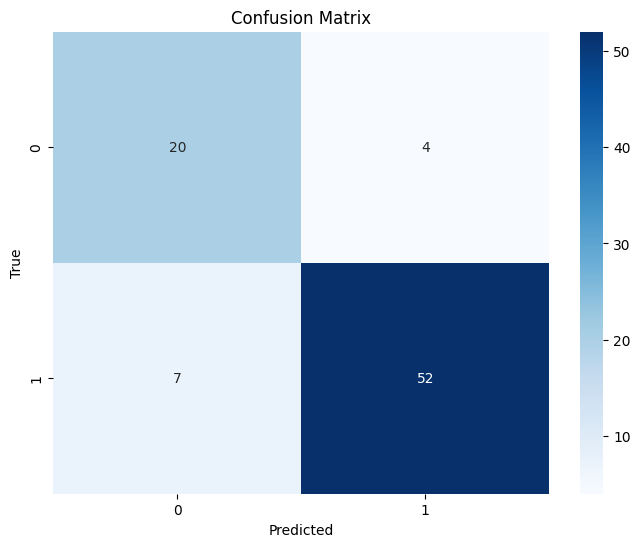

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(packetLossX_test)
#y_true, pred= single_fault_voter(packetLossY_test, pred)
threshold = np.mean(pred)
y_true = packetLossY_test.copy()
pred = (pred > threshold).astype(int)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Gain Data

Classification Report:
3/3 [==============================] - 0s 8ms/step
              precision    recall  f1-score   support

           0       0.27      0.68      0.39        19
           1       0.83      0.45      0.59        64

    accuracy                           0.51        83
   macro avg       0.55      0.57      0.49        83
weighted avg       0.70      0.51      0.54        83

Confusion Matrix:


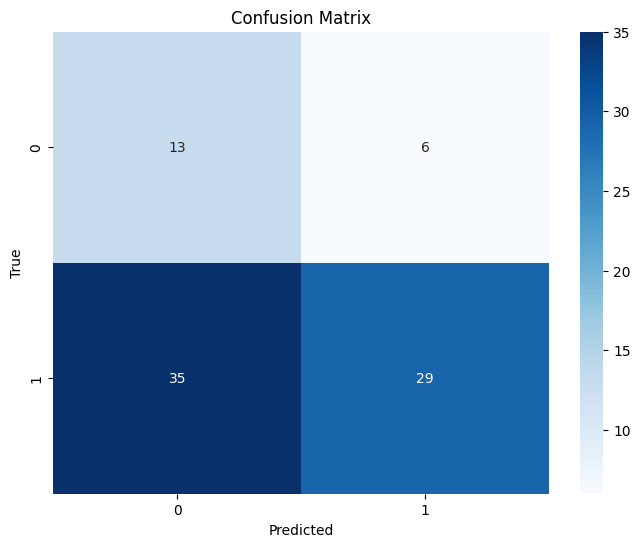

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(gainX_test)
#y_true, pred= single_fault_voter(gainY_test, pred)
pred = (pred > threshold).astype(int)
y_true = gainY_test.copy()
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Noise Data

Classification Report:
3/3 [==============================] - 0s 9ms/step
              precision    recall  f1-score   support

           0       0.55      0.57      0.56        28
           1       0.77      0.76      0.77        54

    accuracy                           0.70        82
   macro avg       0.66      0.67      0.66        82
weighted avg       0.70      0.70      0.70        82

Confusion Matrix:


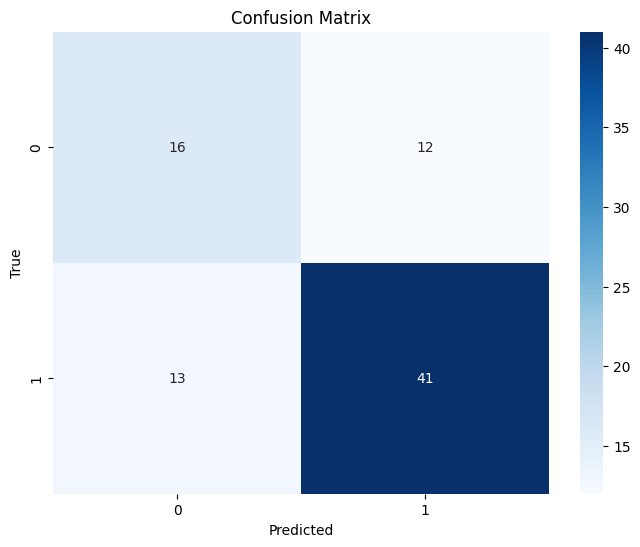

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(noiseX_test)
#y_true, pred= single_fault_voter(noiseY_test, pred)
y_true = noiseY_test.copy()
pred = (pred > threshold).astype(int)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
3/3 [==============================] - 0s 9ms/step
              precision    recall  f1-score   support

           0       0.56      0.41      0.47        34
           1       0.64      0.77      0.70        47

    accuracy                           0.62        81
   macro avg       0.60      0.59      0.59        81
weighted avg       0.61      0.62      0.60        81

Confusion Matrix:


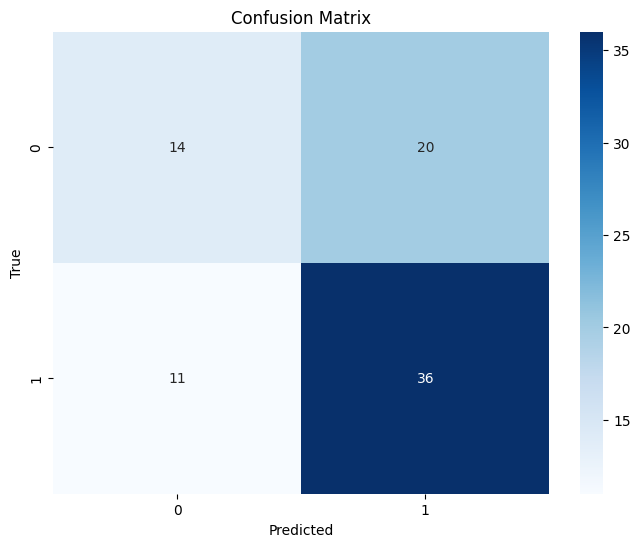

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(delayX_test)
#y_true, pred= single_fault_voter(delayY_test, pred)
y_true = delayY_test.copy()
pred = (pred > threshold).astype(int)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## CONCURRENT FAULTS DETECTION

In [ ]:
# Importing the models
delay_GRUmodel = joblib.load('/content/drive/MyDrive/models/delayGRU_sigmoid002.pkl')
gain_GRUmodel = joblib.load('/content/drive/MyDrive/models/gainGRU_sigmoid002.pkl')
noise_GRUmodel = joblib.load('/content/drive/MyDrive/models/noiseGRU_sigma002.pkl')
packetLoss_GRUmodel = joblib.load('/content/drive/MyDrive/models/packetLossGRU_sigmoid002.pkl')

In [ ]:
delay_GRUmodel = joblib.load('/content/drive/MyDrive/models/delayGRU_model.pkl')
gain_GRUmodel = joblib.load('/content/drive/MyDrive/models/gainGRU_model.pkl')
noise_GRUmodel = joblib.load('/content/drive/MyDrive/models/noiseGRU_model.pkl')
packetLoss_GRUmodel = joblib.load('/content/drive/MyDrive/models/packetLossGRU_model.pkl')

In [ ]:
# Importing the testing data
gainRPM_delayAPP = pd.read_csv('/content/drive/MyDrive/Concurrent file for testring/GainRPM_DelayAPP.csv')
gainRPM_noiseAPP = pd.read_csv('/content/drive/MyDrive/Concurrent file for testring/GainRPM_NoiseAPP.csv')
gainRPM_packetlossAPP = pd.read_csv('/content/drive/MyDrive/Concurrent file for testring/GainRPM_PacketlossAPP.csv')

In [ ]:
cols = ['Timestamp']
gainRPM_delayAPP[cols] = gainRPM_delayAPP[cols].applymap(np.int64)
gainRPM_noiseAPP[cols] = gainRPM_noiseAPP[cols].applymap(np.int64)
gainRPM_packetlossAPP[cols] = gainRPM_packetlossAPP[cols].applymap(np.int64)

In [ ]:
gainRPM_delayAPP['class'] = [0 if i < 180 or i > 300 else 1 for i in gainRPM_delayAPP['Timestamp']]
gainRPM_noiseAPP['class'] = [0 if i < 180 or i > 300 else 1 for i in gainRPM_noiseAPP['Timestamp']]
gainRPM_packetlossAPP['class'] = [0 if i < 180 or i > 300 else 1 for i in gainRPM_packetlossAPP['Timestamp']]

In [ ]:
def concurrent_voter(combined_faults_X, combined_faults_Y, number_of_faults):
  # First, it gets the predictions from each model
  # delay
  pred = delay_GRUmodel.predict(combined_faults_X)
  y_true, y_pred = single_fault_voter(combined_faults_Y, pred)
  delay_acc = accuracy_score(y_true, y_pred)
  # gain
  pred = gain_GRUmodel.predict(combined_faults_X)
  y_true, y_pred = single_fault_voter(combined_faults_Y, pred)
  gain_acc = accuracy_score(y_true, y_pred)
  # noise
  pred = noise_GRUmodel.predict(combined_faults_X)
  y_true, y_pred = single_fault_voter(combined_faults_Y, pred)
  noise_acc = accuracy_score(y_true, y_pred)
  # packet loss
  pred = packetLoss_GRUmodel.predict(combined_faults_X)
  y_true, y_pred = single_fault_voter(combined_faults_Y, pred)
  packetLoss_acc = accuracy_score(y_true, y_pred)

  accuracies = {'F1': delay_acc,
                'F2': gain_acc,
                'F3': noise_acc,
                'F4': packetLoss_acc
                }
  acc_list = [delay_acc, gain_acc, noise_acc, packetLoss_acc]
  selection_index = [acc_list.index(i) for i in sorted(acc_list, reverse=True)][:number_of_faults]
  best_acc = []
  for i in range(len(selection_index)):
    index = selection_index[i]
    best_acc.append(acc_list[index])
  # Decide which faults
  for key, value in accuracies.items():
    if value in best_acc:
      print('There is:{}'.format(str(key)))

In [ ]:
def concurrent_voter_new(combined_faults_X, combined_faults_Y, number_of_faults):
    # First, it gets the predictions from each model
    # delay
    delayGRU_pred = delay_GRUmodel.predict(combined_faults_X)
    gainGRU_pred = gain_GRUmodel.predict(combined_faults_X)
    noiseGRU_pred = noise_GRUmodel.predict(combined_faults_X)
    packetLossGRU_pred = packetLoss_GRUmodel.predict(combined_faults_X)

    combined_faults_Y = combined_faults_Y.argmax(axis=1)


    delayGRU_pred = delayGRU_pred*100
    gainGRU_pred = gainGRU_pred*100
    noiseGRU_pred = noiseGRU_pred*100
    packetLossGRU_pred = packetLossGRU_pred*100
    result_list = []

    for i in range(len(delayGRU_pred)):
        healthy_preds = [delayGRU_pred[i][0], gainGRU_pred[i][0], noiseGRU_pred[i][0], packetLossGRU_pred[i][0]]
        faulty_preds = [delayGRU_pred[i][1], gainGRU_pred[i][1], noiseGRU_pred[i][1], packetLossGRU_pred[i][1]]
        healthy_preds_avg = np.mean(healthy_preds)
        faulty_preds_avg = np.mean(faulty_preds)

        if healthy_preds_avg > faulty_preds_avg:
            result_list.append(0)
        else:
            result_list.append(1)
    result_list = combined_faults_Y
    for i in range(len(result_list)):
        if result_list[i] == 1:
          faulty_preds = [delayGRU_pred[i][1], gainGRU_pred[i][1], noiseGRU_pred[i][1], packetLossGRU_pred[i][1]]
          max_value_index = faulty_preds.index(max(faulty_preds))
          result_list[i] = (max_value_index+1)

    votes_dict = dict(Counter(result_list))

    sorted_result = dict(sorted(votes_dict.items(), key=lambda item: item[1], reverse=True))

    non_zero_keys = [key for key, value in sorted_result.items() if key != 0]

    top_two_keys = non_zero_keys[:number_of_faults]

    total_count = sum(sorted_result.values())

    # Calculate the percentages for each value
    percentage_result = {key: (value / total_count) * 100 for key, value in sorted_result.items()}

    key_mapping = {1: 'F1', 2: 'F2', 3: 'F3', 4: 'F4'}

    total_count = sum(sorted_result.values())

    percentage_result = {key: (value / total_count) * 100 for key, value in sorted_result.items()}


    mapped_percentage_result = {key_mapping[key] if key != 0 else 'healthy': value for key, value in percentage_result.items()}

    mapped_top_two_keys = [key_mapping[key] for key in top_two_keys]


    # Display the result
    print("The votes are (in %):" ,mapped_percentage_result)
    print("Detected faults are:", mapped_top_two_keys)

In [ ]:
def concurrent_voter_new2(combined_faults_X, combined_faults_Y, number_of_faults):
  # First, it gets the predictions from each model
  # delay
  delayGRU_pred = delay_GRUmodel.predict(combined_faults_X)
  gainGRU_pred = gain_GRUmodel.predict(combined_faults_X)
  noiseGRU_pred = noise_GRUmodel.predict(combined_faults_X)
  packetLossGRU_pred = packetLoss_GRUmodel.predict(combined_faults_X)

  y_true, y_pred = single_fault_voter(combined_faults_Y, delayGRU_pred)
  delay_acc = accuracy_score(y_true, y_pred)

  y_true, y_pred = single_fault_voter(combined_faults_Y, gainGRU_pred)
  gain_acc = accuracy_score(y_true, y_pred)

  y_true, y_pred = single_fault_voter(combined_faults_Y, noiseGRU_pred)
  noise_acc = accuracy_score(y_true, y_pred)

  y_true, y_pred = single_fault_voter(combined_faults_Y, packetLossGRU_pred)
  packetLoss_acc = accuracy_score(y_true, y_pred)

  accuracies = {1: delay_acc,
                2: gain_acc,
                3: noise_acc,
                4: packetLoss_acc
                }

  acc_list = [delay_acc, gain_acc, noise_acc, packetLoss_acc]
  sum_acc_list = acc_list/sum(acc_list)
  print(sum_acc_list)
  selection_index = [acc_list.index(i) for i in sorted(acc_list, reverse=True)][:number_of_faults]
  best_acc = []
  for i in range(len(selection_index)):
    index = selection_index[i]
    best_acc.append(acc_list[index])
  # Decide which faults
  best_models = []
  for key, value in accuracies.items():
    if value in best_acc:
      best_models.append(key)
  print(best_models)

  combined_faults_Y = combined_faults_Y.argmax(axis=1)

  result_list = []

  for i in range(len(delayGRU_pred)):
      healthy_preds = [delayGRU_pred[i][0], gainGRU_pred[i][0], noiseGRU_pred[i][0], packetLossGRU_pred[i][0]]
      faulty_preds = [delayGRU_pred[i][1], gainGRU_pred[i][1], noiseGRU_pred[i][1], packetLossGRU_pred[i][1]]
      healthy_preds_avg = np.mean(healthy_preds)
      faulty_preds_avg = np.mean(faulty_preds)
      votes_for_healthy = 0
      votes_for_faulty = 0

      for healthy_value, faulty_value in zip(healthy_preds, faulty_preds):
        if healthy_value > faulty_value:
            votes_for_healthy += 1
        elif healthy_value < faulty_value:
            votes_for_faulty += 1

      if votes_for_healthy > votes_for_faulty:
          result_list.append(0)
      elif votes_for_faulty > votes_for_healthy:
          result_list.append(1)
      elif votes_for_healthy == votes_for_faulty:
          if healthy_preds_avg > faulty_preds_avg:
            result_list.append(0)
          else:
              result_list.append(1)

  result_list = combined_faults_Y

  for i in range(len(result_list)):
      if result_list[i] == 1:
        faulty_preds = [delayGRU_pred[i][1]*sum_acc_list[0], gainGRU_pred[i][1]*sum_acc_list[1], noiseGRU_pred[i][1]*sum_acc_list[2], packetLossGRU_pred[i][1]*sum_acc_list[3]]
        max_value_index = faulty_preds.index(max(faulty_preds))
        result_list[i] = (max_value_index+1)


  votes_dict = dict(Counter(result_list))
  sorted_result = dict(sorted(votes_dict.items(), key=lambda item: item[1], reverse=True))

  non_zero_keys = [key for key, value in sorted_result.items() if key != 0]

  top_two_keys = non_zero_keys[:number_of_faults]

  total_count = sum(sorted_result.values())

  # Calculate the percentages for each value
  percentage_result = {key: (value / total_count) * 100 for key, value in sorted_result.items()}


  key_mapping = {1: 'F1', 2: 'F2', 3: 'F3', 4: 'F4'}

  total_count = sum(sorted_result.values())

  percentage_result = {key: (value / total_count) * 100 for key, value in sorted_result.items()}


  mapped_percentage_result = {key_mapping[key] if key != 0 else 'healthy': value for key, value in percentage_result.items()}

  mapped_top_two_keys = [key_mapping[key] for key in top_two_keys]


  # Display the result
  print("The votes are (in %):" ,mapped_percentage_result)
  print("Detected faults are:", mapped_top_two_keys)

In [ ]:
def concurrent_voter_new3(combined_faults_X, number_of_faults):
    # First, it gets the predictions from each model
    # delay
    delayGRU_pred = delay_GRUmodel.predict(combined_faults_X)
    gainGRU_pred = gain_GRUmodel.predict(combined_faults_X)
    noiseGRU_pred = noise_GRUmodel.predict(combined_faults_X)
    packetLossGRU_pred = packetLoss_GRUmodel.predict(combined_faults_X)

    delayGRU_pred = delayGRU_pred*100
    gainGRU_pred = gainGRU_pred*100
    noiseGRU_pred = noiseGRU_pred*100
    packetLossGRU_pred = packetLossGRU_pred*100

    result_list = []

    for i in range(len(delayGRU_pred)):
        healthy_preds = [delayGRU_pred[i][0], gainGRU_pred[i][0], noiseGRU_pred[i][0], packetLossGRU_pred[i][0]]
        faulty_preds = [delayGRU_pred[i][1], gainGRU_pred[i][1], noiseGRU_pred[i][1], packetLossGRU_pred[i][1]]
        healthy_preds_avg = np.mean(healthy_preds)
        faulty_preds_avg = np.mean(faulty_preds)

        if healthy_preds_avg > faulty_preds_avg:
            result_list.append(0)
        else:
            result_list.append(1)

    for i in range(len(result_list)):
        if result_list[i] == 1:
          faulty_preds = [delayGRU_pred[i][1], gainGRU_pred[i][1], noiseGRU_pred[i][1], packetLossGRU_pred[i][1]]
          max_value_index = faulty_preds.index(min(faulty_preds))
          result_list[i] = (max_value_index+1)

    votes_dict = dict(Counter(result_list))

    sorted_result = dict(sorted(votes_dict.items(), key=lambda item: item[1], reverse=True))

    non_zero_keys = [key for key, value in sorted_result.items() if key != 0]

    top_two_keys = non_zero_keys[:number_of_faults]

    total_count = sum(sorted_result.values())

    # Calculate the percentages for each value
    percentage_result = {key: (value / total_count) * 100 for key, value in sorted_result.items()}


    key_mapping = {1: 'F1', 2: 'F2', 3: 'F3', 4: 'F4'}

    total_count = sum(sorted_result.values())

    percentage_result = {key: (value / total_count) * 100 for key, value in sorted_result.items()}


    mapped_percentage_result = {key_mapping[key] if key != 0 else 'healthy': value for key, value in percentage_result.items()}

    mapped_top_two_keys = [key_mapping[key] for key in top_two_keys]


    # Display the result
    print("The votes are (in %):" ,mapped_percentage_result)
    print("Detected faults are:", mapped_top_two_keys)

### TESTS USING NEW DATA

#### Gain and Delay (F2 and F1)

In [ ]:
gainRPM_delayAPPX_train, gainRPM_delayAPPX_test, gainRPM_delayAPPY_train, gainRPM_delayAPPY_test = make_sequences(gainRPM_delayAPP, test_size=0.99)
data_shape = gainRPM_delayAPPX_train.shape
gainRPM_delayAPPX_train.shape

(4, 20, 7)

In [ ]:
def concurrentVoter(X_test, y_test, number_of_faults):
    delayGRU_preds = delay_GRUmodel.predict(X_test)
    gainGRU_preds = gain_GRUmodel.predict(X_test)
    noiseGRU_preds = noise_GRUmodel.predict(X_test)
    packetLossGRU_preds = packetLoss_GRUmodel.predict(X_test)


    delay_threshold = np.mean(delayGRU_preds)
    gain_threshold = np.mean(gainGRU_preds)
    noise_threshold = np.mean(noiseGRU_preds)
    packetLoss_threshold = np.mean(packetLossGRU_preds)

    max_threshold = 0.5 #max([delay_threshold, gain_threshold, noise_threshold, packetLoss_threshold])
    avg_threshold = (delay_threshold + gain_threshold + noise_threshold + packetLoss_threshold)/4

    threshold = 0.5

    delay_votes = sum(delayGRU_preds > threshold)/len(delayGRU_preds)
    gain_votes = sum(gainGRU_preds > threshold)/len(gainGRU_preds)
    noise_votes = sum(noiseGRU_preds > threshold)/len(noiseGRU_preds)
    packetLoss_votes = sum(packetLossGRU_preds > threshold)/len(packetLossGRU_preds)

    votes = {'F1': delay_votes,
             'F2': gain_votes,
             'F3': noise_votes,
             'F4': packetLoss_votes}
    votes_list = [delay_votes, gain_votes, noise_votes, packetLoss_votes]
    selection_index = [votes_list.index(i) for i in sorted(votes_list, reverse=True)][:number_of_faults]
    best_models = []
    for i in range(len(selection_index)):
      index = selection_index[i]
      best_models.append(votes_list[index])
    for key, value in votes.items():
      if value in best_models:
        print('There is: {} with {} confidence'.format(str(key), str(value)))

In [ ]:
print(delayGRU_preds[10])
print(gainGRU_preds[10])
print(noiseGRU_preds[10])
print(packetLossGRU_preds[10])

[0.9938496]
[0.9494117]
[0.88078743]
[0.17644939]


In [ ]:
zero_list = []
for i in range(len(delayGRU_preds)):
  if (delayGRU_preds[i] < 0.5) and (gainGRU_preds[i] < 0.5) and (noiseGRU_preds[i] < 0.5) and (packetLossGRU_preds[i] < 0.5):
    zero_list.append([delayGRU_preds[i], gainGRU_preds[i], noiseGRU_preds[i], packetLossGRU_preds[i]])
zero_list

[[array([0.27083945], dtype=float32),
  array([0.07870363], dtype=float32),
  array([0.3153285], dtype=float32),
  array([0.22047675], dtype=float32)],
 [array([0.21697429], dtype=float32),
  array([0.03565096], dtype=float32),
  array([0.31748587], dtype=float32),
  array([0.19833], dtype=float32)],
 [array([0.37530845], dtype=float32),
  array([0.21241611], dtype=float32),
  array([0.32234636], dtype=float32),
  array([0.26179594], dtype=float32)],
 [array([0.16026878], dtype=float32),
  array([0.04531098], dtype=float32),
  array([0.3088424], dtype=float32),
  array([0.24890597], dtype=float32)],
 [array([0.277659], dtype=float32),
  array([0.09725565], dtype=float32),
  array([0.31901112], dtype=float32),
  array([0.24709308], dtype=float32)],
 [array([0.2890544], dtype=float32),
  array([0.01462258], dtype=float32),
  array([0.35185403], dtype=float32),
  array([0.17560618], dtype=float32)],
 [array([0.43532172], dtype=float32),
  array([0.48312148], dtype=float32),
  array([0.332

In [ ]:
concurrentVoter(gainRPM_packetlossAPPX_test, gainRPM_packetlossAPPY_test, number_of_faults=2)

12/12 [==============================] - 0s 22ms/step
There is: F1 with [0.74444444] confidence
There is: F4 with [0.73611111] confidence


In [ ]:
delayGRU_preds = delay_GRUmodel.predict(gainRPM_noiseAPPX_test)
gainGRU_preds = gain_GRUmodel.predict(gainRPM_noiseAPPX_test)
noiseGRU_preds = noise_GRUmodel.predict(gainRPM_noiseAPPX_test)
packetLossGRU_preds = packetLoss_GRUmodel.predict(gainRPM_noiseAPPX_test)

13/13 [==============================] - 0s 22ms/step


In [ ]:
sum(noiseGRU_preds > gain_threshold)/len(delayGRU_preds)

array([0.41561713])

In [ ]:

delayGRU_pred = (delayGRU_preds > 0.5).astype(int)
gainGRU_pred = (gainGRU_preds > 0.5).astype(int)
noiseGRU_pred = (noiseGRU_preds > 0.5).astype(int)
packetLossGRU_pred = (packetLossGRU_preds > 0.5).astype(int)

print(accuracy_score(gainRPM_noiseAPPY_test, delayGRU_pred))
print(accuracy_score(gainRPM_noiseAPPY_test, gainGRU_pred))
print(accuracy_score(gainRPM_noiseAPPY_test, noiseGRU_pred))
print(accuracy_score(gainRPM_noiseAPPY_test, packetLossGRU_pred))


0.5050505050505051
0.48737373737373735
0.49242424242424243
0.8888888888888888


In [ ]:
Counter(gainRPM_noiseAPPY_test)
np.unique(packetLossGRU_pred, return_counts=True)

(array([0, 1]), array([240, 156]))

In [ ]:
delayTrue, delayGRU_votes = single_fault_voter(gainRPM_delayAPPY_test, delayGRU_preds)
gainTrue, gainGRU_votes = single_fault_voter(gainRPM_delayAPPY_test, gainGRU_preds)
noiseTrue, noiseGRU_votes = single_fault_voter(gainRPM_delayAPPY_test, noiseGRU_preds)
packetLossTrue, packetLossGRU_votes = single_fault_voter(gainRPM_delayAPPY_test, packetLossGRU_preds)

In [ ]:
delay_acc = accuracy_score(delayTrue, delayGRU_votes)
gain_acc = accuracy_score(delayTrue, gainGRU_votes)
noise_acc = accuracy_score(noiseTrue, noiseGRU_votes)
packetLoss_acc = accuracy_score(packetLossTrue, packetLossGRU_votes)

In [ ]:
delayGRU_pred = delayGRU_preds*delay_acc
gainGRU_pred = gainGRU_preds*gain_acc
noiseGRU_pred = noiseGRU_preds*noise_acc
packetLossGRU_pred = packetLossGRU_preds*packetLoss_acc

In [ ]:
result_list = []

for i in range(len(delayGRU_preds)):
    healthy_preds = [delayGRU_pred[i][0], gainGRU_pred[i][0], noiseGRU_pred[i][0], packetLossGRU_pred[i][0]]
    faulty_preds = [delayGRU_pred[i][1], gainGRU_pred[i][1], noiseGRU_pred[i][1], packetLossGRU_pred[i][1]]
    healthy_preds_avg = np.mean(healthy_preds)
    faulty_preds_avg = np.mean(faulty_preds)
    votes_for_healthy = 0
    votes_for_faulty = 0

    for healthy_value, faulty_value in zip(healthy_preds, faulty_preds):
      if healthy_value > faulty_value:
          votes_for_healthy += 1
      elif healthy_value < faulty_value:
          votes_for_faulty += 1

    if votes_for_healthy > votes_for_faulty:
        result_list.append(0)
    elif votes_for_faulty > votes_for_healthy:
        result_list.append(1)
    elif votes_for_healthy == votes_for_faulty:
        if healthy_preds_avg > faulty_preds_avg:
          result_list.append(0)
        else:
            result_list.append(1)

In [ ]:
accuracy_score(packetLossTrue, result_list)

0.8111702127659575

In [ ]:
for i in range(len(result_list)):
      if result_list[i] == 1:
        faulty_preds = [delayGRU_pred[i][1], gainGRU_pred[i][1], noiseGRU_pred[i][1], packetLossGRU_pred[i][1]]
        max_value_index = faulty_preds.index(max(faulty_preds))
        result_list[i] = (max_value_index+1)

In [ ]:
votes_dict = dict(Counter(result_list))
votes_dict

{0: 255, 1: 104, 3: 4, 4: 13}

In [ ]:
concurrent_voter(gainRPM_delayAPPX_test,gainRPM_delayAPPY_test, number_of_faults=2)

12/12 [==============================] - 1s 15ms/step
There is:F1
There is:F3


In [ ]:
concurrent_voter_new(gainRPM_delayAPPX_test,gainRPM_delayAPPX_test, number_of_faults=2)

12/12 [==============================] - 0s 19ms/step


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
concurrent_voter_new2(gainRPM_delayAPPX_test,gainRPM_delayAPPY_test, number_of_faults=2)

12/12 [==============================] - 0s 13ms/step
[0.37708831 0.13484487 0.27804296 0.21002387]
[1, 3]
The votes are (in %): {'healthy': 70.74468085106383, 'F1': 21.27659574468085, 'F4': 7.446808510638298, 'F3': 0.5319148936170213}
Detected faults are: ['F1', 'F4']


#### Gain and Noise (F2 and F3)

In [ ]:
gainRPM_noiseAPPX_train, gainRPM_noiseAPPX_test, gainRPM_noiseAPPY_train, gainRPM_noiseAPPY_test = make_sequences(gainRPM_noiseAPP, test_size=0.99)
data_shape = gainRPM_noiseAPPX_train.shape
gainRPM_noiseAPPX_train.shape

(4, 20, 7)

In [ ]:
concurrent_voter(gainRPM_noiseAPPX_test,gainRPM_noiseAPPY_test, number_of_faults=2)

13/13 [==============================] - 0s 9ms/step
There is:F1
There is:F3


In [ ]:
concurrent_voter_new(gainRPM_noiseAPPX_test, gainRPM_noiseAPPY_test, number_of_faults=2)

13/13 [==============================] - 0s 9ms/step
The votes are (in %): {'healthy': 69.94949494949495, 'F2': 28.78787878787879, 'F4': 0.7575757575757576, 'F1': 0.5050505050505051}
Detected faults are: ['F2', 'F4']


In [ ]:
concurrent_voter_new2(gainRPM_noiseAPPX_test,gainRPM_noiseAPPY_test, number_of_faults=2)

13/13 [==============================] - 0s 8ms/step
[0.28196721 0.20218579 0.30273224 0.21311475]
[1, 3]
The votes are (in %): {'healthy': 69.94949494949495, 'F1': 29.040404040404038, 'F4': 1.0101010101010102}
Detected faults are: ['F1', 'F4']


#### Gain and Packet Loss (F2 and F4)

In [ ]:
gainRPM_packetlossAPPX_train, gainRPM_packetlossAPPX_test, gainRPM_packetlossAPPY_train, gainRPM_packetlossAPPY_test = make_sequences(gainRPM_packetlossAPP, test_size=0.90)
data_shape = gainRPM_packetlossAPPX_train.shape
gainRPM_packetlossAPPX_train.shape

(40, 20, 7)

In [ ]:
concurrent_voter(gainRPM_packetlossAPPX_test,gainRPM_packetlossAPPY_test, number_of_faults=2)

12/12 [==============================] - 0s 8ms/step
There is:F3
There is:F4


In [ ]:
concurrent_voter_new(gainRPM_packetlossAPPX_test,gainRPM_packetlossAPPX_test, number_of_faults=2)

12/12 [==============================] - 0s 11ms/step


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
concurrent_voter_new2(gainRPM_packetlossAPPX_test,gainRPM_packetlossAPPY_test, number_of_faults=2)

12/12 [==============================] - 0s 8ms/step
[0.22701476 0.22360953 0.28603859 0.26333712]
[3, 4]
The votes are (in %): {'healthy': 70.0, 'F4': 30.0}
Detected faults are: ['F4']


### TESTS USING OLD DATA

#### Gain and Noise (F2 and F3)

In [ ]:
combined_X_test = np.concatenate((gainX_test, noiseX_test), axis=0)
combined_Y_test = np.concatenate((gainY_test, noiseY_test), axis=0)

In [ ]:
concurrentVoter(combined_X_test,combined_Y_test, number_of_faults=2)

6/6 [==============================] - 0s 15ms/step
There is: F1 with [0.5030303] confidence
There is: F2 with [0.84242424] confidence


In [ ]:
concurrent_voter_new(combined_X_test, number_of_faults=2)

TypeError: concurrent_voter_new() missing 1 required positional argument: 'combined_faults_Y'

In [ ]:
concurrent_voter_new2(combined_X_test,combined_Y_test, number_of_faults=2)

6/6 [==============================] - 0s 12ms/step
[0.31111111 0.3037037  0.12592593 0.25925926]
[1, 2]
The votes are (in %): {'F1': 41.358024691358025, 'healthy': 31.48148148148148, 'F2': 24.691358024691358, 'F4': 2.4691358024691357}
Detected faults are: ['F1', 'F2']


#### Delay and Gain (F1 and F2)

In [ ]:
combined_X_test = np.concatenate((delayX_test, gainX_test), axis=0)
combined_Y_test = np.concatenate((delayY_test, gainY_test), axis=0)

In [ ]:
concurrent_voter(combined_X_test, combined_Y_test, number_of_faults=2)

6/6 [==============================] - 0s 9ms/step
There is:F1
There is:F2
There is:F4


In [ ]:
concurrent_voter_new(combined_X_test, number_of_faults=2)

106/106 [==============================] - 0s 4ms/step
The votes are (in %): {'F1': 33.69952494061758, 'F3': 30.314726840855105, 'F2': 14.10332541567696, 'healthy': 12.648456057007126, 'F4': 9.233966745843231}
Detected faults are: ['F1', 'F3']


In [ ]:
concurrent_voter_new2(combined_X_test, combined_Y_test, number_of_faults=2)

106/106 [==============================] - 0s 3ms/step
[0.8144299287410927, 0.7707838479809976, 0.5890736342042755, 0.702790973871734]
[1, 2]
The votes are (in %): {'F1': 54.66152019002375, 'F2': 28.889548693586697, 'healthy': 12.648456057007126, 'F4': 3.622327790973872, 'F3': 0.17814726840855108}
Detected faults are: ['F1', 'F2']


#### Delay, Gain and Noise (F1, F2 and F3)

In [ ]:
combined_X_test = np.concatenate((delayX_test, gainX_test, noiseX_test), axis=0)
combined_Y_test = np.concatenate((delayY_test, gainY_test, noiseY_test), axis=0)

In [ ]:
concurrent_voter(combined_X_test,combined_Y_test , number_of_faults=3)

158/158 [==============================] - 0s 3ms/step
There is:F1
There is:F2
There is:F3


In [ ]:
concurrent_voter_new(combined_X_test, number_of_faults=3)

158/158 [==============================] - 0s 3ms/step
The votes are (in %): {'F1': 37.60886777513856, 'F3': 29.730799683293746, 'healthy': 12.688044338875692, 'F4': 9.996041171813143, 'F2': 9.97624703087886}
Detected faults are: ['F1', 'F3', 'F4']


In [ ]:
concurrent_voter_new2(combined_X_test, combined_Y_test, number_of_faults=3)

158/158 [==============================] - 1s 3ms/step
[0.7868171021377672, 0.7304038004750594, 0.7171417260490894, 0.7131828978622328]
[1, 2, 3]
The votes are (in %): {'F1': 53.95882818685669, 'F2': 29.948535233570862, 'healthy': 12.688044338875692, 'F3': 1.741884402216944, 'F4': 1.66270783847981}
Detected faults are: ['F1', 'F2', 'F3']


#### Testing Different Data Sizes

##### 70% training, 30% testing

Delay APP

In [ ]:
combined_data = pd.concat([healthy_data, delay_app], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
delayX_train, delayX_test, delayY_train, delayY_test = make_sequences(combined_data, test_size=0.3)
data_shape = delayX_train.shape

#### Gain RPM

In [ ]:
combined_data = pd.concat([healthy_data, gain_rpm], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
gainX_train, gainX_test, gainY_train, gainY_test = make_sequences(combined_data, test_size=0.3)

#### Noise APP

In [ ]:
combined_data = pd.concat([healthy_data, noise_app], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
noiseX_train, noiseX_test, noiseY_train, noiseY_test = make_sequences(combined_data, test_size=0.3)

#### PacketLoss APP

In [ ]:
combined_data = pd.concat([healthy_data, packetLoss_app], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
packetLossX_train, packetLossX_test, packetLossY_train, packetLossY_test = make_sequences(combined_data, test_size=0.3)

In [ ]:
delay_GRUmodel = joblib.load('/content/drive/MyDrive/models/delayGRU_70pct_data_model.pkl')
gain_GRUmodel = joblib.load('/content/drive/MyDrive/models/gainGRU_60pct_data_model.pkl')
noise_GRUmodel = joblib.load('/content/drive/MyDrive/models/noiseGRU_70pct_data_model.pkl')
packetLoss_GRUmodel = joblib.load('/content/drive/MyDrive/models/packetLossGRU_70pct_data_model.pkl')

## DELAY GRU

##### Delay-GRU

In [ ]:
delay_GRUmodel = build_model(num_classes=2, units=70, learning_rate=0.001, momentum=0.99, optimizer='adam')
delay_GRUmodel.fit(delayX_train, delayY_train,batch_size=10, epochs=80)
joblib.dump(delay_GRUmodel, '/content/drive/MyDrive/models/delayGRU_70pct_data_model.pkl')

Model compiled!
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_12 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_13 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_14 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_15 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_3 (Bat  (None, 70)                280       
 chNormalization)                                                
                                                                 
 dense_3 (Dense)             (None, 2)                 142       
                                      

['/content/drive/MyDrive/models/delayGRU_70pct_data_model.pkl']

##### Single Fault Detection Tests

##### Delay Data

In [ ]:
delay_GRUmodel = model

Classification Report:
53/53 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       695
           1       0.97      0.95      0.96       989

    accuracy                           0.95      1684
   macro avg       0.95      0.96      0.95      1684
weighted avg       0.96      0.95      0.95      1684

Confusion Matrix:


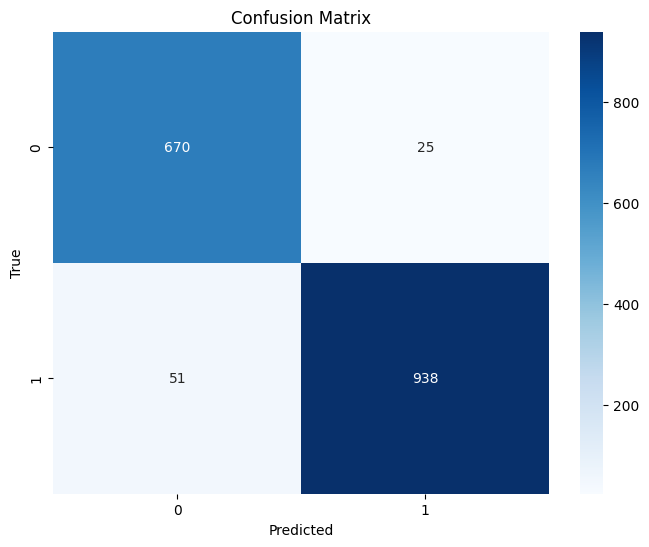

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Gain Data

Classification Report:
3/3 [==============================] - 1s 17ms/step
              precision    recall  f1-score   support

           0       0.21      0.94      0.35        18
           1       0.75      0.05      0.09        66

    accuracy                           0.24        84
   macro avg       0.48      0.49      0.22        84
weighted avg       0.63      0.24      0.14        84

Confusion Matrix:


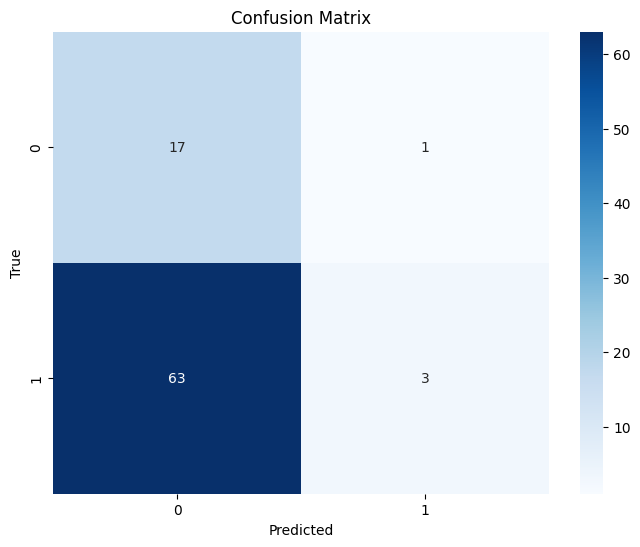

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

#### Noise Data

Classification Report:
155/155 [==============================] - 3s 19ms/step
              precision    recall  f1-score   support

           0       0.56      0.51      0.53      3429
           1       0.07      0.09      0.08      1530

    accuracy                           0.38      4959
   macro avg       0.31      0.30      0.31      4959
weighted avg       0.41      0.38      0.39      4959

Confusion Matrix:


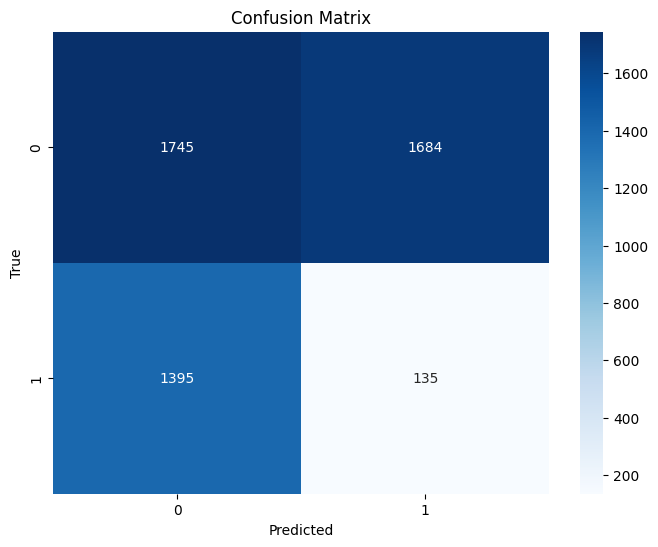

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
155/155 [==============================] - 4s 26ms/step
              precision    recall  f1-score   support

           0       0.73      0.45      0.56      3137
           1       0.43      0.71      0.53      1817

    accuracy                           0.55      4954
   macro avg       0.58      0.58      0.54      4954
weighted avg       0.62      0.55      0.55      4954

Confusion Matrix:


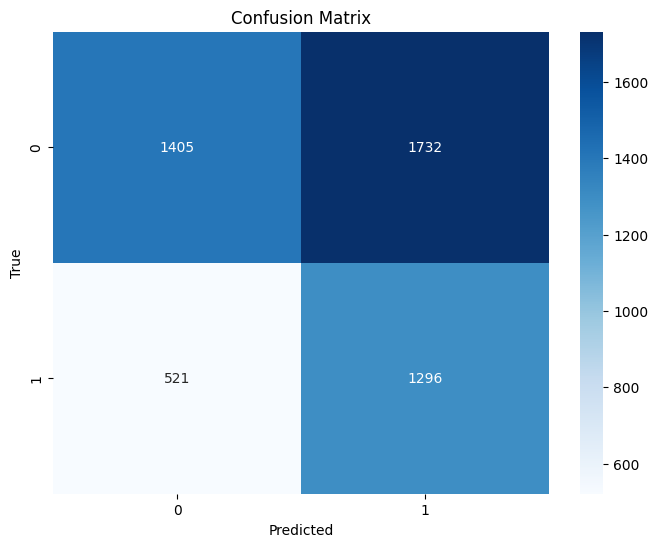

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## GAIN RPM Model

#### GainRPM-GRU Hyperparameter Tuning

In [ ]:
gain_GRUmodel = build_model(num_classes=2,units=70, learning_rate=0.0001, momentum=0.99, optimizer='adam')
gain_GRUmodel.fit(gainX_train, gainY_train,batch_size=50, epochs=80)
joblib.dump(delay_GRUmodel, '/content/drive/MyDrive/models/gainGRU_60pct_data_model.pkl')

Model compiled!
Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_28 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_29 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_30 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_31 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_7 (Bat  (None, 70)                280       
 chNormalization)                                                
                                                                 
 dense_7 (Dense)             (None, 2)                 142       
                                      

['/content/drive/MyDrive/models/gainGRU_60pct_data_model.pkl']

#### Single Fault Detections Tests

##### Gain Data

Classification Report:
156/156 [==============================] - 5s 23ms/step
              precision    recall  f1-score   support

           0       0.82      0.73      0.77      3079
           1       0.63      0.73      0.68      1896

    accuracy                           0.73      4975
   macro avg       0.72      0.73      0.72      4975
weighted avg       0.74      0.73      0.74      4975

Confusion Matrix:


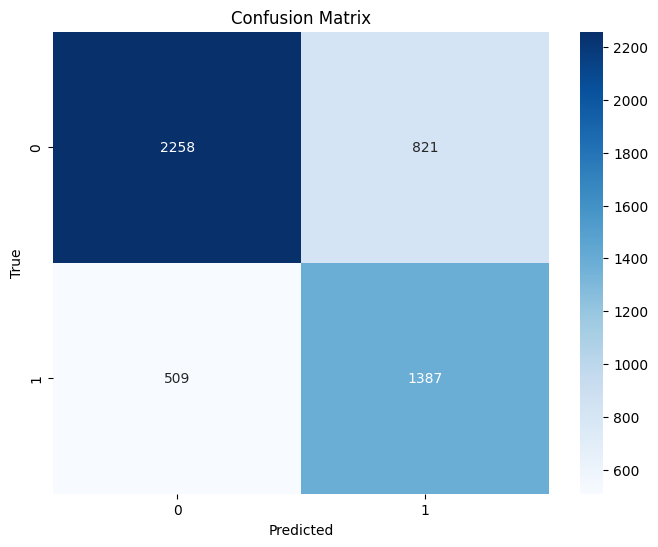

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Noise Data

Classification Report:
155/155 [==============================] - 4s 25ms/step
              precision    recall  f1-score   support

           0       0.66      0.38      0.49      3429
           1       0.29      0.56      0.38      1530

    accuracy                           0.44      4959
   macro avg       0.48      0.47      0.43      4959
weighted avg       0.55      0.44      0.45      4959

Confusion Matrix:


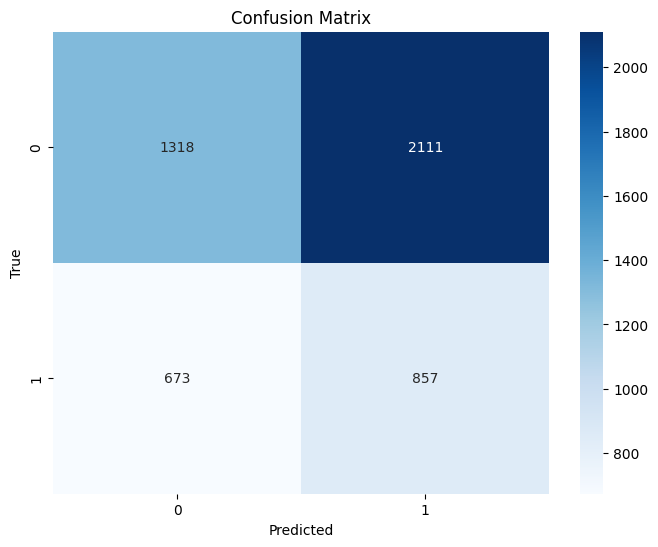

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
40/40 [==============================] - 1s 24ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1221
           1       0.89      0.56      0.69        59

    accuracy                           0.98      1280
   macro avg       0.94      0.78      0.84      1280
weighted avg       0.98      0.98      0.97      1280

Confusion Matrix:


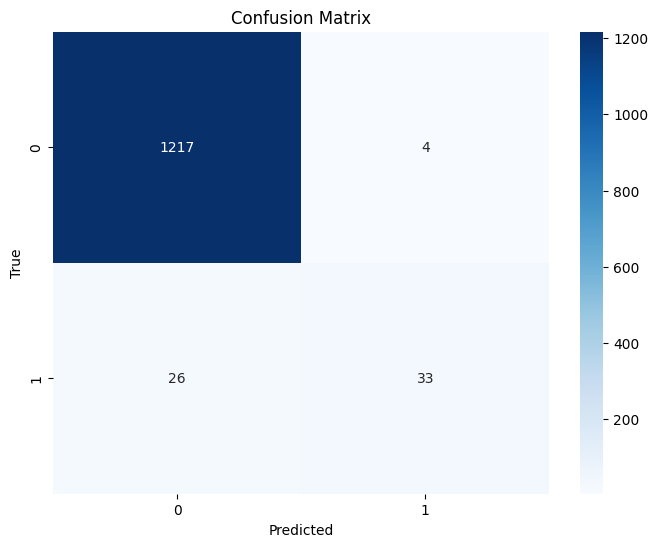

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
155/155 [==============================] - 5s 30ms/step
              precision    recall  f1-score   support

           0       0.79      0.45      0.58      3137
           1       0.46      0.79      0.58      1817

    accuracy                           0.58      4954
   macro avg       0.62      0.62      0.58      4954
weighted avg       0.67      0.58      0.58      4954

Confusion Matrix:


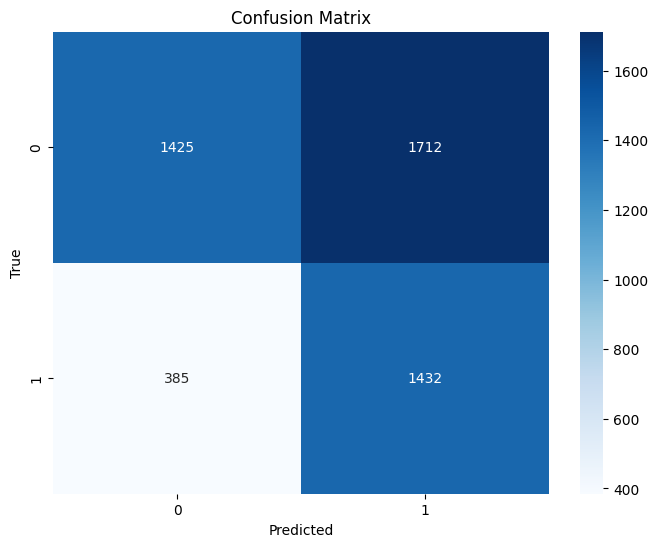

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## NOISE APP model

#### Noise APP Hyperparameter Tuning

In [ ]:
noise_GRUmodel = build_model(num_classes=2,units=70, learning_rate=0.001, momentum=0.99, optimizer='adam')
noise_GRUmodel.fit(noiseX_train, noiseY_train,batch_size=30, epochs=80)
joblib.dump(noise_GRUmodel, '/content/drive/MyDrive/models/noiseGRU_70pct_data_model.pkl')

Model compiled!
Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_52 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_53 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_54 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_55 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_13 (Ba  (None, 70)                280       
 tchNormalization)                                               
                                                                 
 dense_13 (Dense)            (None, 2)                 142       
                                     

['/content/drive/MyDrive/models/noiseGRU_70pct_data_model.pkl']

#### Single Fault Detections Tests

##### Noise Data

Classification Report:
155/155 [==============================] - 5s 26ms/step
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3429
           1       0.97      0.99      0.98      1530

    accuracy                           0.99      4959
   macro avg       0.98      0.99      0.99      4959
weighted avg       0.99      0.99      0.99      4959

Confusion Matrix:


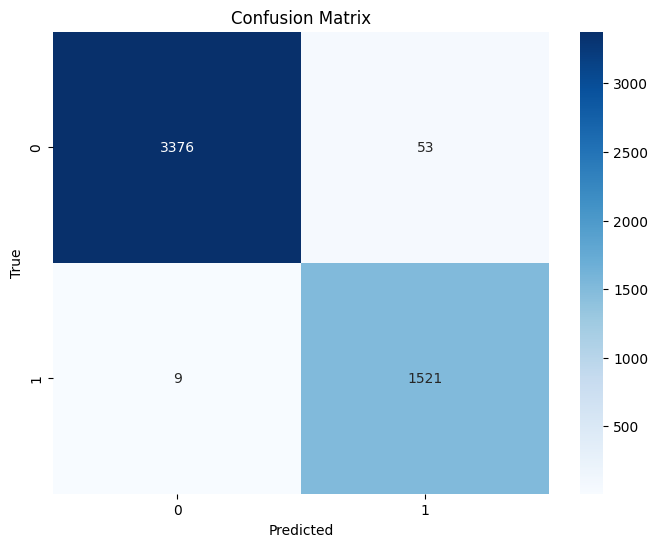

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
40/40 [==============================] - 1s 25ms/step
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1221
           1       0.01      0.05      0.01        59

    accuracy                           0.61      1280
   macro avg       0.47      0.34      0.38      1280
weighted avg       0.89      0.61      0.72      1280

Confusion Matrix:


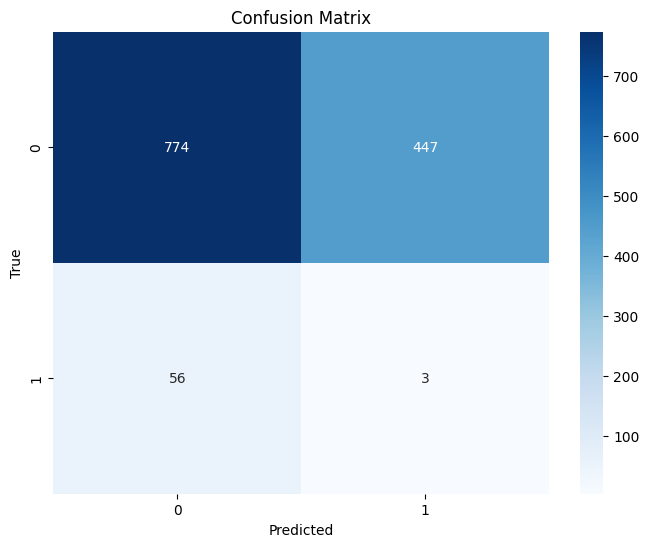

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

#### Gain Data

Classification Report:
156/156 [==============================] - 4s 22ms/step
              precision    recall  f1-score   support

           0       0.56      0.65      0.60      3079
           1       0.25      0.19      0.21      1896

    accuracy                           0.47      4975
   macro avg       0.41      0.42      0.41      4975
weighted avg       0.44      0.47      0.45      4975

Confusion Matrix:


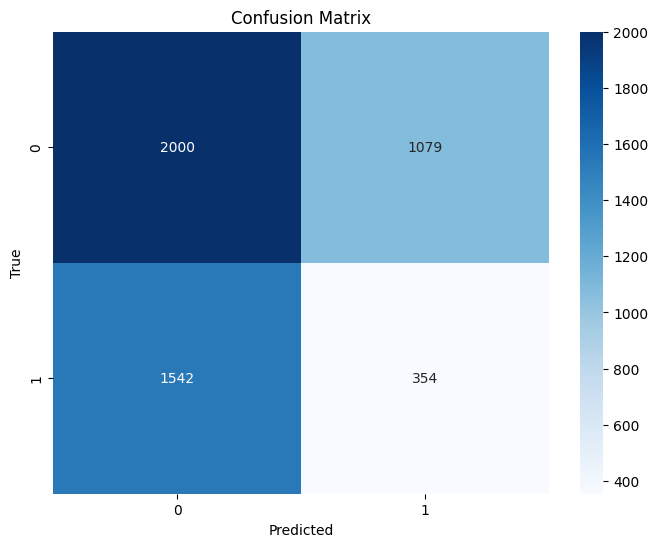

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
155/155 [==============================] - 3s 18ms/step
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      3137
           1       0.54      0.54      0.54      1817

    accuracy                           0.66      4954
   macro avg       0.63      0.63      0.63      4954
weighted avg       0.66      0.66      0.66      4954

Confusion Matrix:


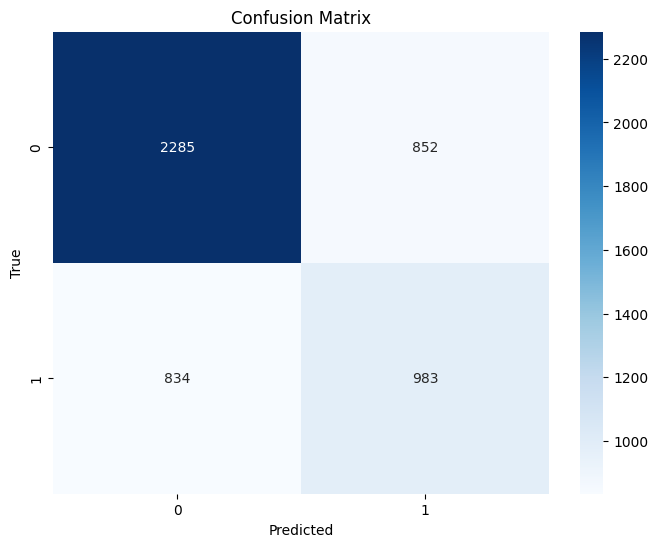

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## PACKETLOSS APP model

#### PacketLossAPP-GRU Hyperparameter Tuning

In [ ]:
packetLoss_GRUmodel = build_model(num_classes=2, units=70, learning_rate=0.0001, momentum=0.01, optimizer='adam')
packetLoss_GRUmodel.fit(packetLossX_train, packetLossY_train,batch_size=30, epochs=50)
joblib.dump(packetLoss_GRUmodel, '/content/drive/MyDrive/models/packetLossGRU_70pct_data_model.pkl')

Model compiled!
Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_56 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_57 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_58 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_59 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_14 (Ba  (None, 70)                280       
 tchNormalization)                                               
                                                                 
 dense_14 (Dense)            (None, 2)                 142       
                                     

['/content/drive/MyDrive/models/packetLossGRU_70pct_data_model.pkl']

##### Single Fault Detection Tests

##### Packet Loss Data

Classification Report:
155/155 [==============================] - 5s 26ms/step
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      3137
           1       0.94      0.81      0.87      1817

    accuracy                           0.91      4954
   macro avg       0.92      0.89      0.90      4954
weighted avg       0.91      0.91      0.91      4954

Confusion Matrix:


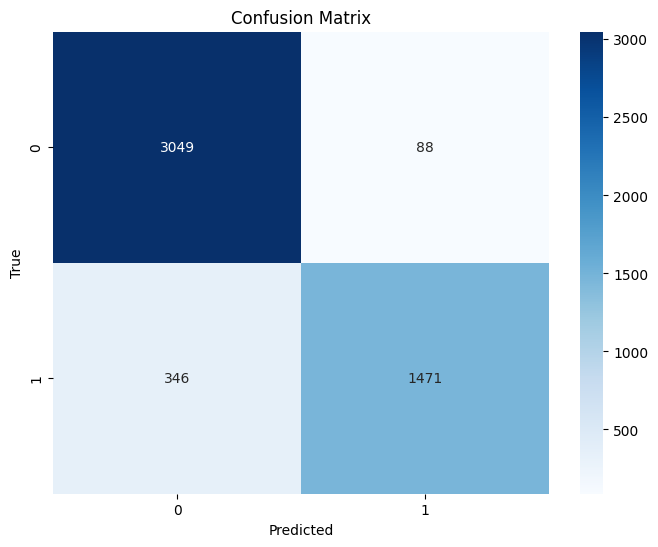

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Gain Data

Classification Report:
156/156 [==============================] - 4s 26ms/step
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      3079
           1       0.70      0.64      0.67      1896

    accuracy                           0.76      4975
   macro avg       0.74      0.73      0.74      4975
weighted avg       0.75      0.76      0.75      4975

Confusion Matrix:


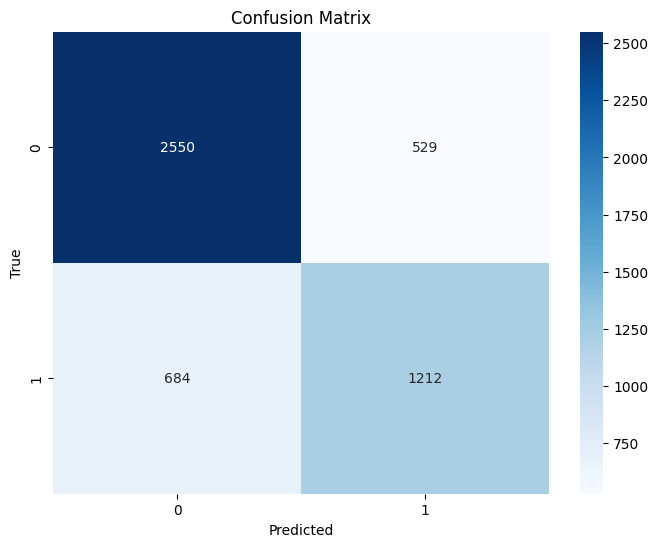

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Noise Data

Classification Report:
155/155 [==============================] - 3s 19ms/step
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      3429
           1       0.42      0.42      0.42      1530

    accuracy                           0.64      4959
   macro avg       0.58      0.58      0.58      4959
weighted avg       0.64      0.64      0.64      4959

Confusion Matrix:


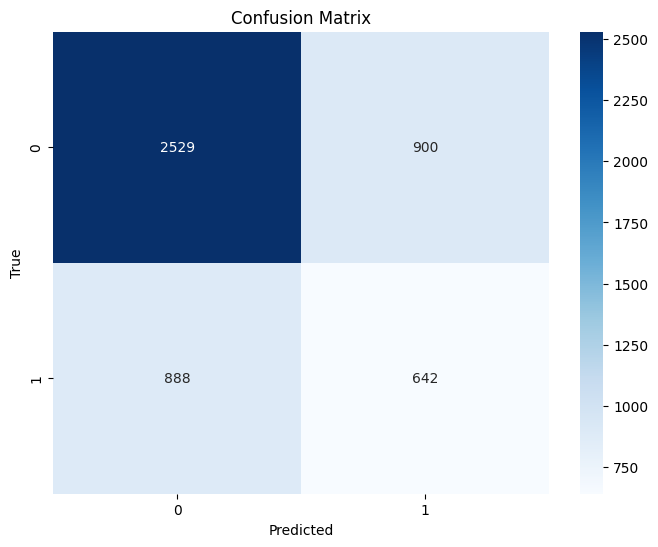

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
40/40 [==============================] - 1s 16ms/step
              precision    recall  f1-score   support

           0       0.94      0.36      0.52      1221
           1       0.04      0.56      0.08        59

    accuracy                           0.37      1280
   macro avg       0.49      0.46      0.30      1280
weighted avg       0.90      0.37      0.50      1280

Confusion Matrix:


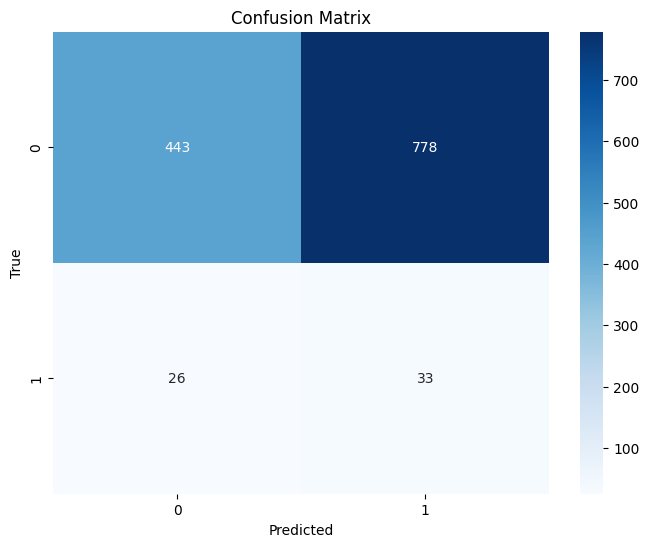

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## CONCURRENT FAULTS DETECTION

In [ ]:
delay_GRUmodel = joblib.load('/content/drive/MyDrive/models/delayGRU_model4.pkl')
gain_GRUmodel = joblib.load('/content/drive/MyDrive/models/gainGRU_model.pkl')
noise_GRUmodel = joblib.load('/content/drive/MyDrive/models/noiseGRU_model.pkl')
packetLoss_GRUmodel = joblib.load('/content/drive/MyDrive/models/packetLosGRU_model.pkl')


FileNotFoundError: ignored

In [ ]:
models_dict = {
    "delay_model": delay_GRUmodel,
    "gain_model": gain_GRUmodel,
    "noise_model": noise_GRUmodel,
    "packetLos_model": packetLoss_GRUmodel,
}
data_dict = {
    "F1": [delayX_test, delayY_test],
    "F2": [gainX_test, gainY_test],
    "F3": [noiseX_test, noiseY_test],
    "F4": [packetLossX_test, packetLossY_test],
}
concurent_faultsVoter(models_dict, data_dict)

155/155 [==============================] - 3s 18ms/step


{'F1': {'delay_model': 0.978125,
  'gain_model': 0.9765625,
  'noise_model': 0.60703125,
  'packetLos_model': 0.371875},
 'F2': {'delay_model': 0.5612060301507538,
  'gain_model': 0.7326633165829146,
  'noise_model': 0.47316582914572863,
  'packetLos_model': 0.7561809045226131},
 'F3': {'delay_model': 0.3791086912684009,
  'gain_model': 0.43859649122807015,
  'noise_model': 0.9874974793305101,
  'packetLos_model': 0.6394434361766486},
 'F4': {'delay_model': 0.5452159870811466,
  'gain_model': 0.5767056923698022,
  'noise_model': 0.6596689543802987,
  'packetLos_model': 0.9123940250302786}}

##### 60% Training Data and 40% testing Data

Delay APP

In [ ]:
combined_data = pd.concat([healthy_data, delay_app], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
delayX_train, delayX_test, delayY_train, delayY_test = make_sequences(combined_data, test_size=0.4)
data_shape = delayX_train.shape

#### Gain RPM

In [ ]:
combined_data = pd.concat([healthy_data, gain_rpm], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
gainX_train, gainX_test, gainY_train, gainY_test = make_sequences(combined_data, test_size=0.4)

#### Noise APP

In [ ]:
combined_data = pd.concat([healthy_data, noise_app], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
noiseX_train, noiseX_test, noiseY_train, noiseY_test = make_sequences(combined_data, test_size=0.4)

#### PacketLoss APP

In [ ]:
combined_data = pd.concat([healthy_data, packetLoss_app], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
packetLossX_train, packetLossX_test, packetLossY_train, packetLossY_test = make_sequences(combined_data, test_size=0.4)

## DELAY GRU

#### Delay-GRU Training

In [ ]:
delay_GRUmodel = build_model(num_classes=2, units=70, learning_rate=0.001, momentum=0.99, optimizer='adam')
delay_GRUmodel.fit(delayX_train, delayY_train,batch_size=10, epochs=80)
joblib.dump(delay_GRUmodel, '/content/drive/MyDrive/models/delayGRU_60pct_data_model.pkl')

Model compiled!
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_16 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_17 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_18 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_19 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_4 (Bat  (None, 70)                280       
 chNormalization)                                                
                                                                 
 dense_4 (Dense)             (None, 2)                 142       
                                      

['/content/drive/MyDrive/models/delayGRU_60pct_data_model.pkl']

##### Single Fault Detection Tests

In [ ]:
delayGRU_model = joblib.load('/content/drive/MyDrive/models/delayGRU_60pct_data_model.pkl')

##### Delay Data

Classification Report:
67/67 [==============================] - 1s 15ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2017
           1       0.89      0.63      0.74       116

    accuracy                           0.98      2133
   macro avg       0.93      0.81      0.86      2133
weighted avg       0.97      0.98      0.97      2133

Confusion Matrix:


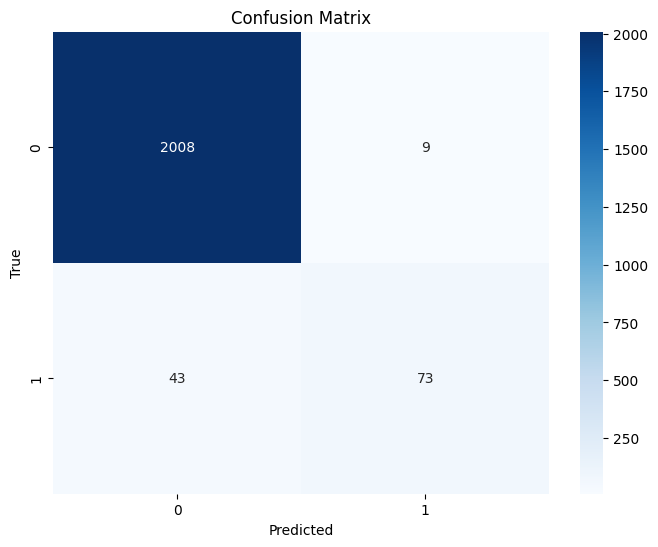

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Gain Data

Classification Report:
156/156 [==============================] - 4s 26ms/step
              precision    recall  f1-score   support

           0       0.82      0.73      0.77      3079
           1       0.63      0.73      0.68      1896

    accuracy                           0.73      4975
   macro avg       0.72      0.73      0.72      4975
weighted avg       0.74      0.73      0.74      4975

Confusion Matrix:


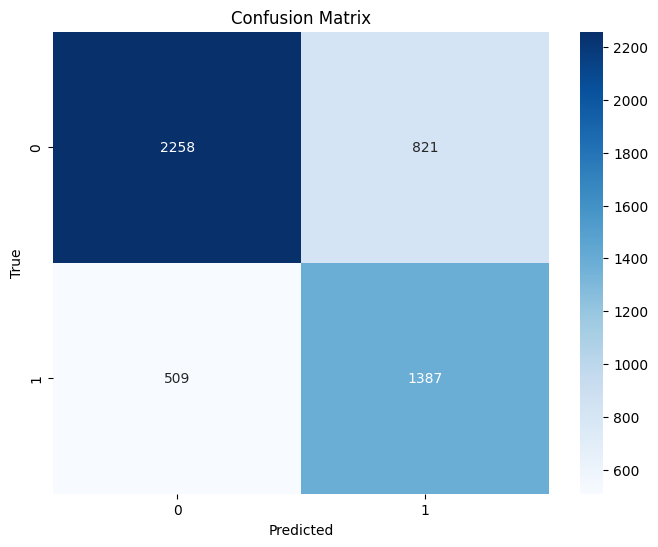

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

#### Noise Data

Classification Report:
155/155 [==============================] - 3s 20ms/step
              precision    recall  f1-score   support

           0       0.66      0.38      0.49      3429
           1       0.29      0.56      0.38      1530

    accuracy                           0.44      4959
   macro avg       0.48      0.47      0.43      4959
weighted avg       0.55      0.44      0.45      4959

Confusion Matrix:


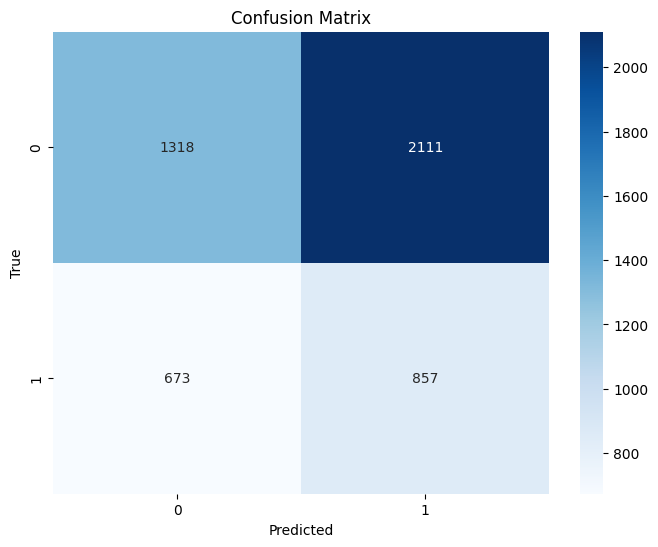

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
155/155 [==============================] - 2s 15ms/step
              precision    recall  f1-score   support

           0       0.79      0.45      0.58      3137
           1       0.46      0.79      0.58      1817

    accuracy                           0.58      4954
   macro avg       0.62      0.62      0.58      4954
weighted avg       0.67      0.58      0.58      4954

Confusion Matrix:


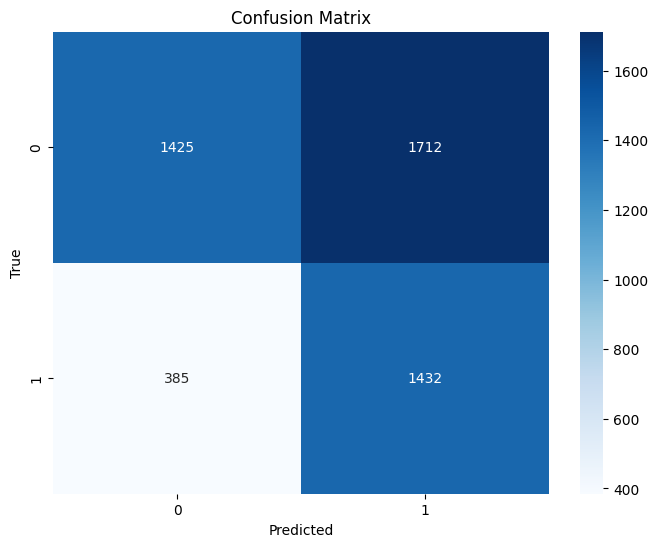

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## GAIN RPM Model

#### GainRPM-GRU Hyperparameter Tuning

In [ ]:
gain_GRUmodel = build_model(num_classes=2,units=70, learning_rate=0.0001, momentum=0.99, optimizer='adam')
gain_GRUmodel.fit(gainX_train, gainY_train,batch_size=50, epochs=80)
joblib.dump(delay_GRUmodel, '/content/drive/MyDrive/models/gainGRU_60pct_data_model.pkl')

Model compiled!
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_24 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_25 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_26 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_27 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_6 (Bat  (None, 70)                280       
 chNormalization)                                                
                                                                 
 dense_6 (Dense)             (None, 2)                 142       
                                      

['/content/drive/MyDrive/models/gainGRU_60pct_data_model.pkl']

#### Single Fault Classification Tests

#### Single Fault Detections Tests

##### Gain Data

Classification Report:
156/156 [==============================] - 4s 22ms/step
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3079
           1       0.99      0.93      0.96      1896

    accuracy                           0.97      4975
   macro avg       0.97      0.96      0.97      4975
weighted avg       0.97      0.97      0.97      4975

Confusion Matrix:


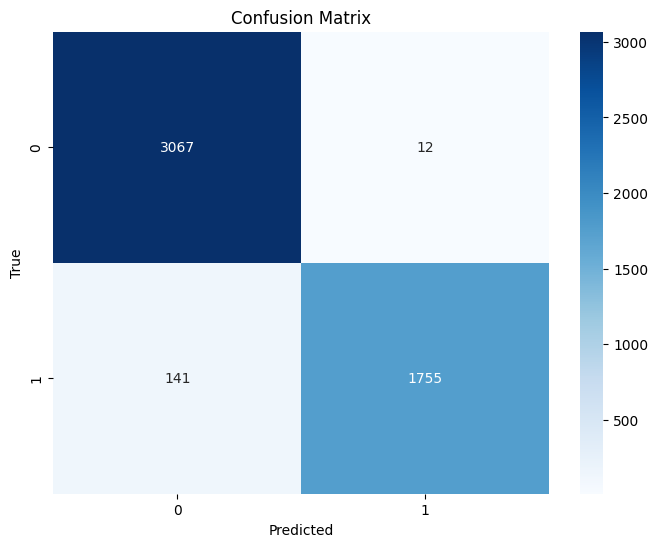

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Noise Data

Classification Report:
155/155 [==============================] - 5s 32ms/step
              precision    recall  f1-score   support

           0       0.79      0.88      0.83      3429
           1       0.64      0.49      0.55      1530

    accuracy                           0.76      4959
   macro avg       0.72      0.68      0.69      4959
weighted avg       0.75      0.76      0.75      4959

Confusion Matrix:


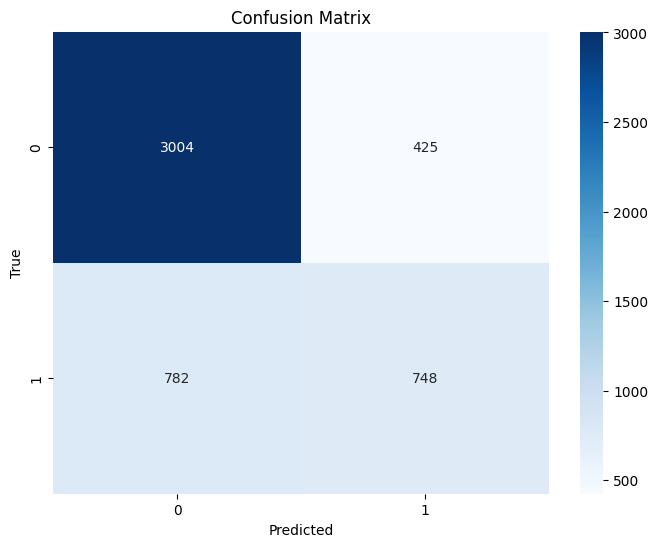

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
67/67 [==============================] - 1s 14ms/step
              precision    recall  f1-score   support

           0       0.92      0.50      0.65      2017
           1       0.03      0.28      0.06       116

    accuracy                           0.49      2133
   macro avg       0.48      0.39      0.35      2133
weighted avg       0.87      0.49      0.62      2133

Confusion Matrix:


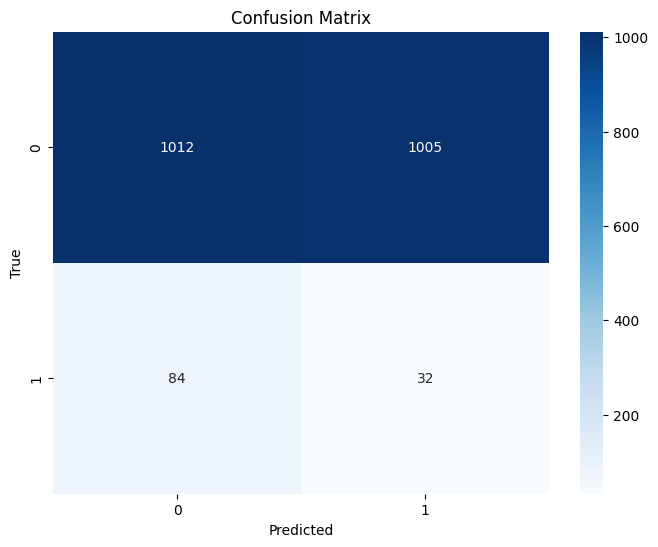

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
155/155 [==============================] - 3s 22ms/step
              precision    recall  f1-score   support

           0       0.77      0.96      0.85      3137
           1       0.87      0.50      0.64      1817

    accuracy                           0.79      4954
   macro avg       0.82      0.73      0.75      4954
weighted avg       0.81      0.79      0.77      4954

Confusion Matrix:


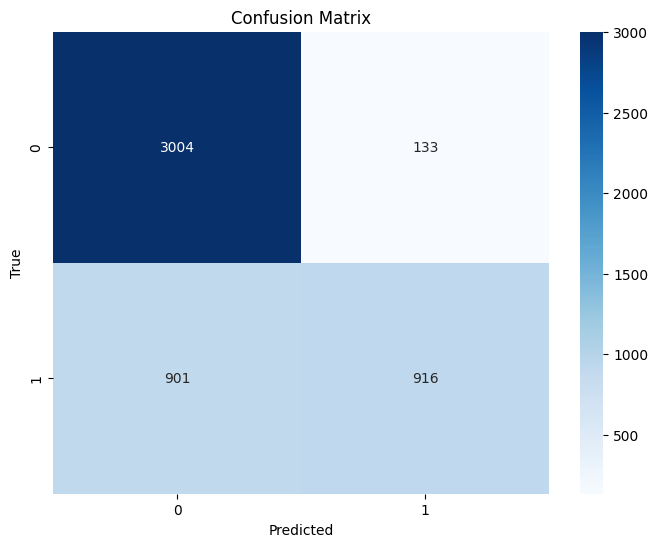

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## NOISE APP model

#### Noise APP Hyperparameter Tuning

In [ ]:
noise_GRUmodel = build_model(num_classes=2,units=70, learning_rate=0.001, momentum=0.99, optimizer='adam')
noise_GRUmodel.fit(noiseX_train, noiseY_train,batch_size=30, epochs=80)
joblib.dump(noise_GRUmodel, '/content/drive/MyDrive/models/noiseGRU_60pct_data_model.pkl')


Model compiled!
Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_32 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_33 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_34 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_35 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_8 (Bat  (None, 70)                280       
 chNormalization)                                                
                                                                 
 dense_8 (Dense)             (None, 2)                 142       
                                      

['/content/drive/MyDrive/models/noiseGRU_60pct_data_model.pkl']

#### Single Fault Detections Tests

##### Noise Data

Classification Report:
155/155 [==============================] - 4s 16ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3429
           1       1.00      0.99      0.99      1530

    accuracy                           1.00      4959
   macro avg       1.00      0.99      0.99      4959
weighted avg       1.00      1.00      1.00      4959

Confusion Matrix:


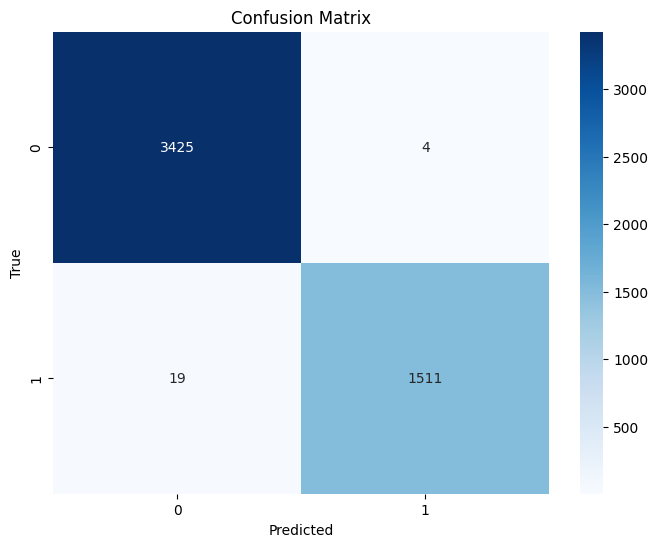

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
67/67 [==============================] - 1s 15ms/step
              precision    recall  f1-score   support

           0       0.91      0.53      0.67      2017
           1       0.01      0.10      0.02       116

    accuracy                           0.51      2133
   macro avg       0.46      0.32      0.35      2133
weighted avg       0.86      0.51      0.64      2133

Confusion Matrix:


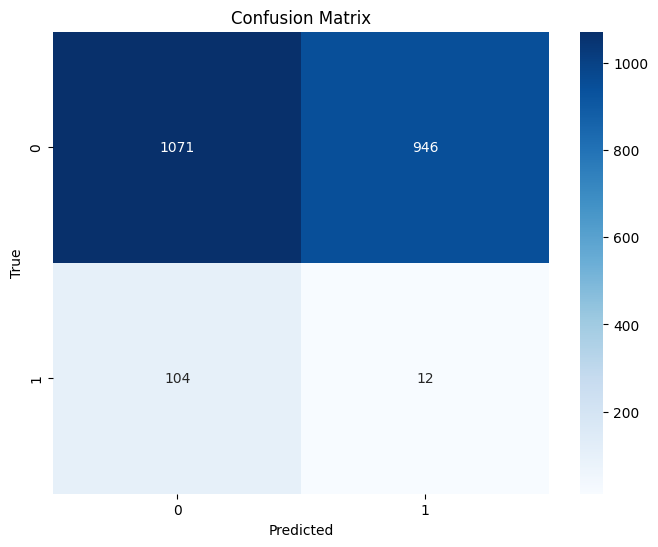

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

#### Gain Data

Classification Report:
156/156 [==============================] - 2s 15ms/step
              precision    recall  f1-score   support

           0       0.60      0.78      0.68      3079
           1       0.29      0.14      0.19      1896

    accuracy                           0.54      4975
   macro avg       0.44      0.46      0.43      4975
weighted avg       0.48      0.54      0.49      4975

Confusion Matrix:


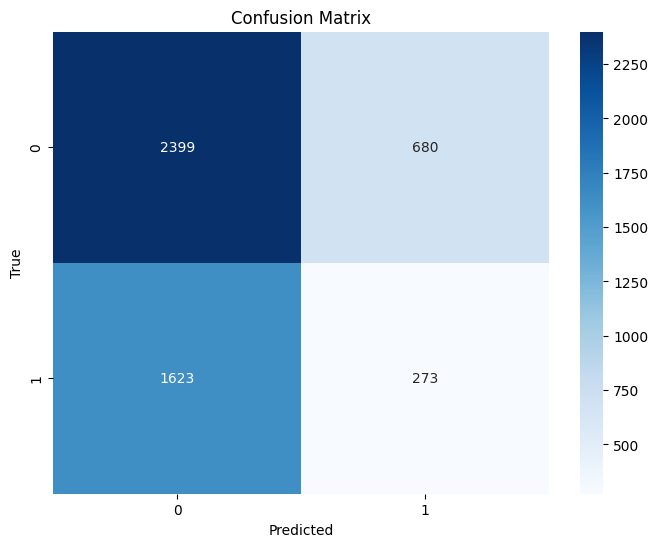

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
155/155 [==============================] - 2s 15ms/step
              precision    recall  f1-score   support

           0       0.76      0.90      0.82      3137
           1       0.74      0.50      0.60      1817

    accuracy                           0.75      4954
   macro avg       0.75      0.70      0.71      4954
weighted avg       0.75      0.75      0.74      4954

Confusion Matrix:


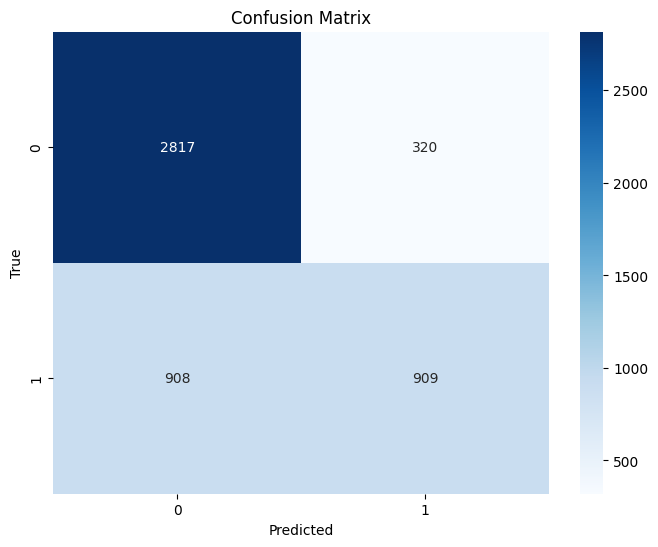

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## PACKETLOSS APP model

#### PacketLossAPP-GRU Hyperparameter Tuning

In [ ]:
packetLoss_GRUmodel = build_model(num_classes=2, units=70, learning_rate=0.0001, momentum=0.01, optimizer='adam')
packetLoss_GRUmodel.fit(packetLossX_train, packetLossY_train,batch_size=30, epochs=50)
joblib.dump(packetLoss_GRUmodel, '/content/drive/MyDrive/models/packetLossGRU_50pct_data_model.pkl')

Model compiled!
Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_36 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_37 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_38 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_39 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_9 (Bat  (None, 70)                280       
 chNormalization)                                                
                                                                 
 dense_9 (Dense)             (None, 2)                 142       
                                      

['/content/drive/MyDrive/models/packetLossGRU_50pct_data_model.pkl']

##### Single Fault Detection Tests

##### Packet Loss Data

Classification Report:
155/155 [==============================] - 3s 17ms/step
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      3137
           1       1.00      0.77      0.87      1817

    accuracy                           0.92      4954
   macro avg       0.94      0.89      0.90      4954
weighted avg       0.93      0.92      0.91      4954

Confusion Matrix:


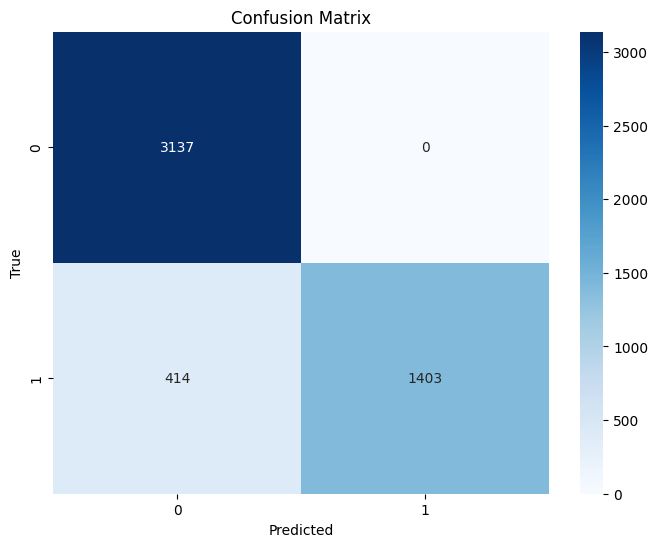

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Gain Data

Classification Report:
156/156 [==============================] - 4s 22ms/step
              precision    recall  f1-score   support

           0       0.79      0.89      0.84      3079
           1       0.78      0.61      0.68      1896

    accuracy                           0.78      4975
   macro avg       0.78      0.75      0.76      4975
weighted avg       0.78      0.78      0.78      4975

Confusion Matrix:


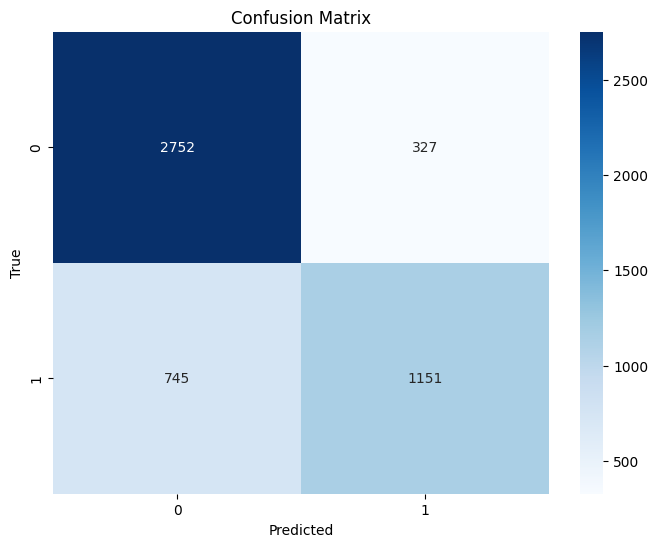

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Noise Data

Classification Report:
155/155 [==============================] - 3s 22ms/step
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      3429
           1       0.58      0.71      0.64      1530

    accuracy                           0.75      4959
   macro avg       0.72      0.74      0.73      4959
weighted avg       0.77      0.75      0.76      4959

Confusion Matrix:


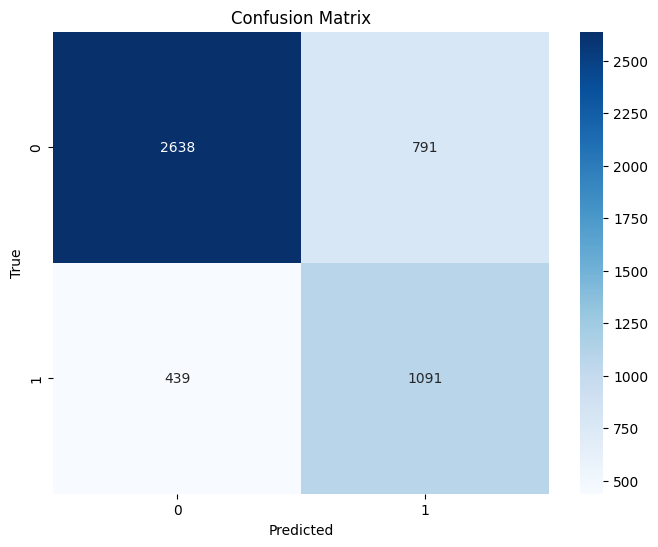

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
67/67 [==============================] - 2s 23ms/step
              precision    recall  f1-score   support

           0       0.94      0.49      0.64      2017
           1       0.05      0.43      0.08       116

    accuracy                           0.48      2133
   macro avg       0.49      0.46      0.36      2133
weighted avg       0.89      0.48      0.61      2133

Confusion Matrix:


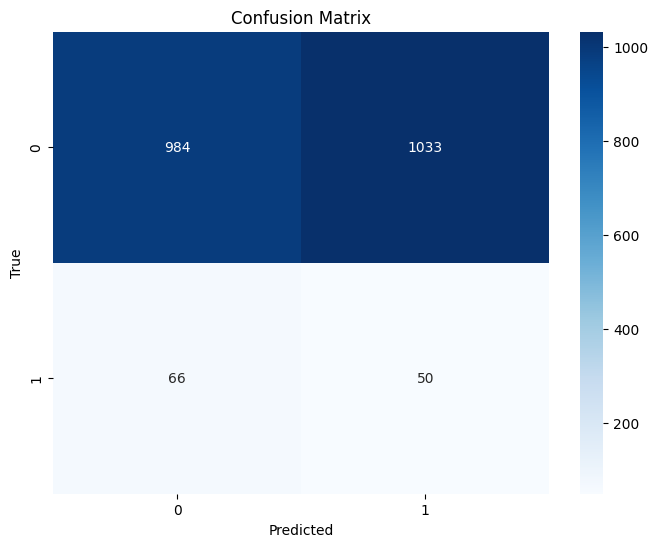

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## CONCURRENT FAULTS DETECTION

In [ ]:
delay_GRUmodel = joblib.load('/content/drive/MyDrive/models/delayGRU_model.pkl')
gain_GRUmodel = joblib.load('/content/drive/MyDrive/models/gainGRU_model.pkl')
noise_GRUmodel = joblib.load('/content/drive/MyDrive/models/noiseGRU_model.pkl')
packetLoss_GRUmodel = joblib.load('/content/drive/MyDrive/models/packetLosGRU_model.pkl')


In [ ]:
models_dict = {
    "delay_model": delay_GRUmodel,
    "gain_model": gain_GRUmodel,
    "noise_model": noise_GRUmodel,
    "packetLos_model": packetLoss_GRUmodel,
}
data_dict = {
    "F1": [delayX_test, delayY_test],
    "F2": [gainX_test, gainY_test],
    "F3": [noiseX_test, noiseY_test],
    "F4": [packetLossX_test, packetLossY_test],
}
concurent_faultsVoter(models_dict, data_dict)

155/155 [==============================] - 3s 21ms/step


{'F1': {'delay_model': 0.9756211908110642,
  'gain_model': 0.48945147679324896,
  'noise_model': 0.5077355836849508,
  'packetLos_model': 0.48476324425691514},
 'F2': {'delay_model': 0.7326633165829146,
  'gain_model': 0.9692462311557789,
  'noise_model': 0.5370854271356784,
  'packetLos_model': 0.7845226130653267},
 'F3': {'delay_model': 0.43859649122807015,
  'gain_model': 0.7566041540633193,
  'noise_model': 0.9953619681387377,
  'packetLos_model': 0.7519661222020568},
 'F4': {'delay_model': 0.5767056923698022,
  'gain_model': 0.7912797739200645,
  'noise_model': 0.7521194993944288,
  'packetLos_model': 0.9164311667339523}}

##### 50% training Data and 50% testing Data

## DELAY GRU

Delay APP

In [ ]:
combined_data = pd.concat([healthy_data, delay_app], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
delayX_train, delayX_test, delayY_train, delayY_test = make_sequences(combined_data, test_size=0.5)
data_shape = delayX_train.shape

#### Gain RPM

In [ ]:
combined_data = pd.concat([healthy_data, gain_rpm], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
gainX_train, gainX_test, gainY_train, gainY_test = make_sequences(combined_data, test_size=0.5)

#### Noise APP

In [ ]:
combined_data = pd.concat([healthy_data, noise_app], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
noiseX_train, noiseX_test, noiseY_train, noiseY_test = make_sequences(combined_data, test_size=0.5)

#### PacketLoss APP

In [ ]:
combined_data = pd.concat([healthy_data, packetLoss_app], ignore_index=True)
combined_data = combined_data.dropna(axis=1)
packetLossX_train, packetLossX_test, packetLossY_train, packetLossY_test = make_sequences(combined_data, test_size=0.5)

#### Delay-GRU

In [ ]:
delay_GRUmodel = build_model(num_classes=2, units=70, learning_rate=0.001, momentum=0.99, optimizer='adam')
delay_GRUmodel.fit(delayX_train, delayY_train,batch_size=10, epochs=80)
joblib.dump(delay_GRUmodel, '/content/drive/MyDrive/models/delayGRU_50pct_data_model.pkl')

Model compiled!
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_20 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_21 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_22 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_23 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_5 (Bat  (None, 70)                280       
 chNormalization)                                                
                                                                 
 dense_5 (Dense)             (None, 2)                 142       
                                      

['/content/drive/MyDrive/models/delayGRU_50pct_data_model.pkl']

##### Single Fault Detection Tests

In [ ]:
delay_GRUmodel = joblib.load('/content/drive/MyDrive/models/delayGRU_50pct_data_model.pkl')

##### Delay Data

Classification Report:
67/67 [==============================] - 2s 16ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2017
           1       0.89      0.63      0.74       116

    accuracy                           0.98      2133
   macro avg       0.93      0.81      0.86      2133
weighted avg       0.97      0.98      0.97      2133

Confusion Matrix:


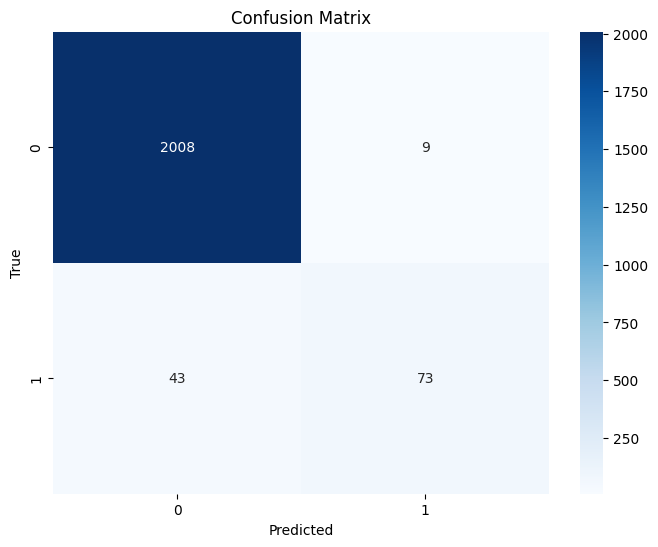

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Gain Data

Classification Report:
156/156 [==============================] - 2s 14ms/step
              precision    recall  f1-score   support

           0       0.82      0.73      0.77      3079
           1       0.63      0.73      0.68      1896

    accuracy                           0.73      4975
   macro avg       0.72      0.73      0.72      4975
weighted avg       0.74      0.73      0.74      4975

Confusion Matrix:


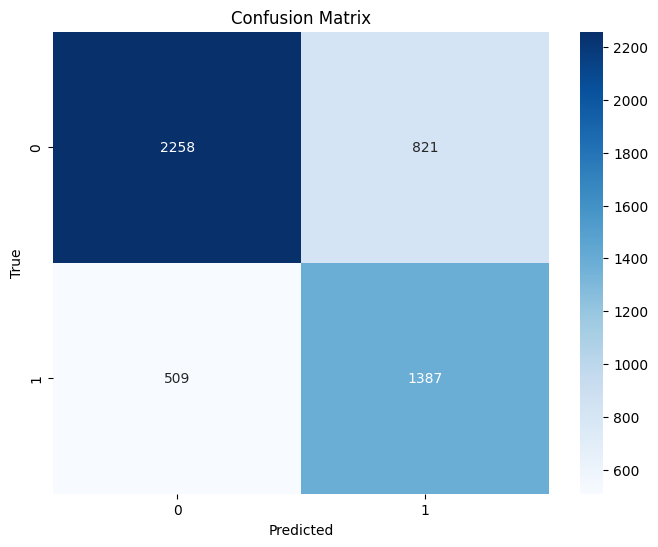

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

#### Noise Data

Classification Report:
155/155 [==============================] - 4s 23ms/step
              precision    recall  f1-score   support

           0       0.66      0.38      0.49      3429
           1       0.29      0.56      0.38      1530

    accuracy                           0.44      4959
   macro avg       0.48      0.47      0.43      4959
weighted avg       0.55      0.44      0.45      4959

Confusion Matrix:


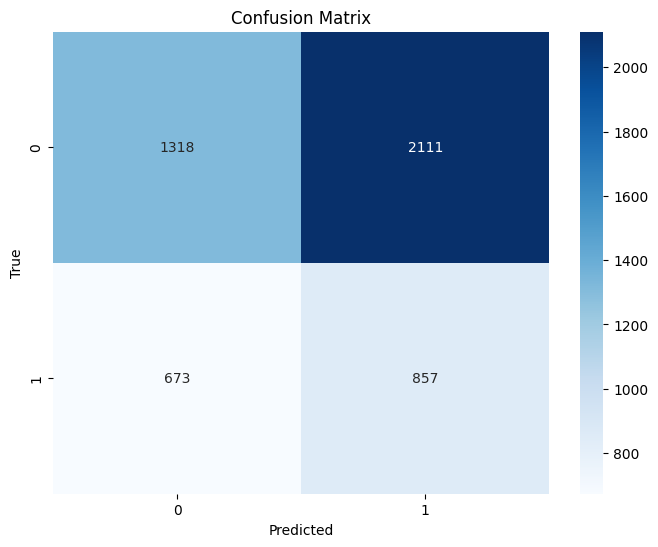

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
155/155 [==============================] - 3s 18ms/step
              precision    recall  f1-score   support

           0       0.79      0.45      0.58      3137
           1       0.46      0.79      0.58      1817

    accuracy                           0.58      4954
   macro avg       0.62      0.62      0.58      4954
weighted avg       0.67      0.58      0.58      4954

Confusion Matrix:


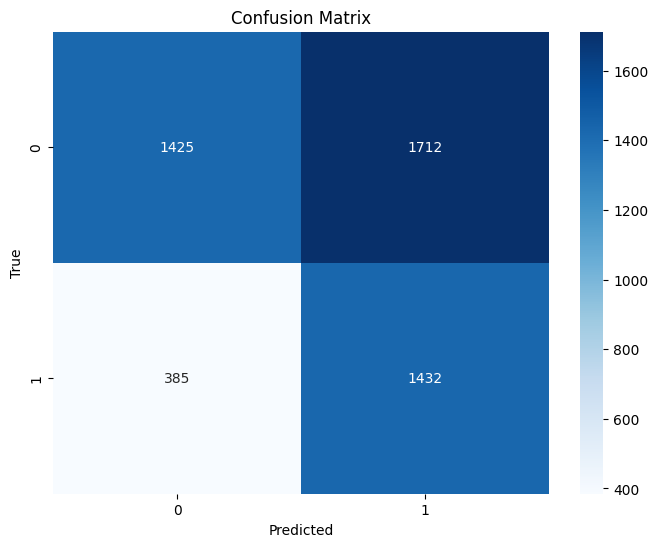

In [ ]:
print("Classification Report:")
pred = delay_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## GAIN RPM Model

#### GainRPM-GRU Hyperparameter Tuning

In [ ]:
gain_GRUmodel = build_model(num_classes=2,units=70, learning_rate=0.0001, momentum=0.99, optimizer='adam')
gain_GRUmodel.fit(gainX_train, gainY_train,batch_size=50, epochs=80)
joblib.dump(delay_GRUmodel, '/content/drive/MyDrive/models/gainGRU_50pct_data_model.pkl')

Model compiled!
Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_40 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_41 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_42 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_43 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_10 (Ba  (None, 70)                280       
 tchNormalization)                                               
                                                                 
 dense_10 (Dense)            (None, 2)                 142       
                                     

['/content/drive/MyDrive/models/gainGRU_50pct_data_model.pkl']

#### Single Fault Classification Tests

#### Single Fault Detections Tests

##### Gain Data

Classification Report:
260/260 [==============================] - 6s 18ms/step
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      5048
           1       0.99      0.93      0.96      3244

    accuracy                           0.97      8292
   macro avg       0.98      0.96      0.97      8292
weighted avg       0.97      0.97      0.97      8292

Confusion Matrix:


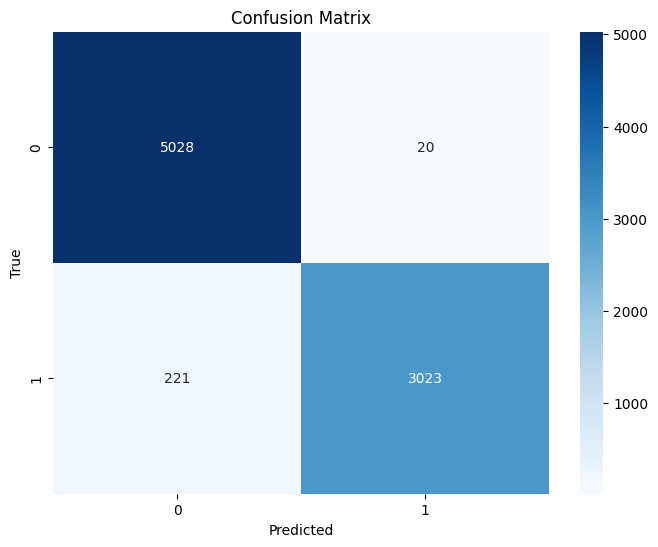

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Noise Data

Classification Report:
259/259 [==============================] - 12s 44ms/step
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      5684
           1       0.67      0.54      0.60      2581

    accuracy                           0.77      8265
   macro avg       0.74      0.71      0.72      8265
weighted avg       0.76      0.77      0.77      8265

Confusion Matrix:


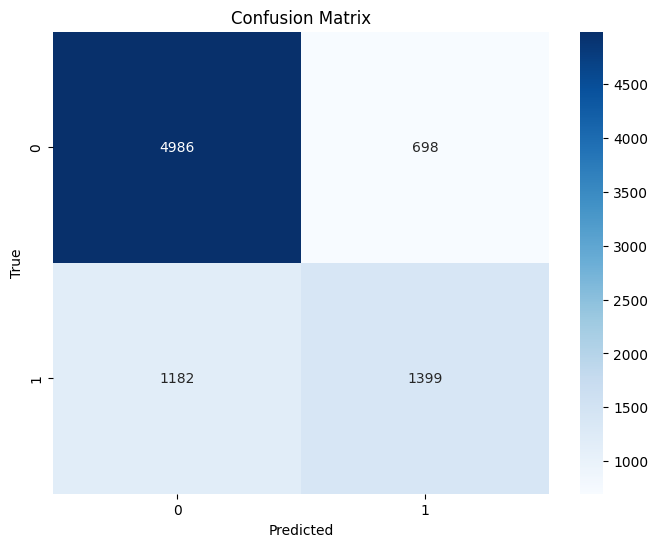

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
67/67 [==============================] - 2s 25ms/step
              precision    recall  f1-score   support

           0       0.96      0.54      0.69      2017
           1       0.08      0.65      0.13       116

    accuracy                           0.55      2133
   macro avg       0.52      0.59      0.41      2133
weighted avg       0.92      0.55      0.66      2133

Confusion Matrix:


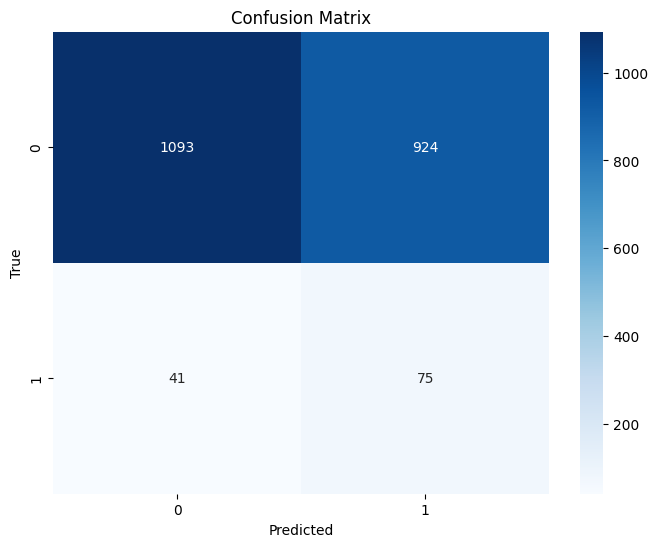

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
258/258 [==============================] - 5s 21ms/step
              precision    recall  f1-score   support

           0       0.77      0.90      0.83      5210
           1       0.77      0.54      0.63      3046

    accuracy                           0.77      8256
   macro avg       0.77      0.72      0.73      8256
weighted avg       0.77      0.77      0.76      8256

Confusion Matrix:


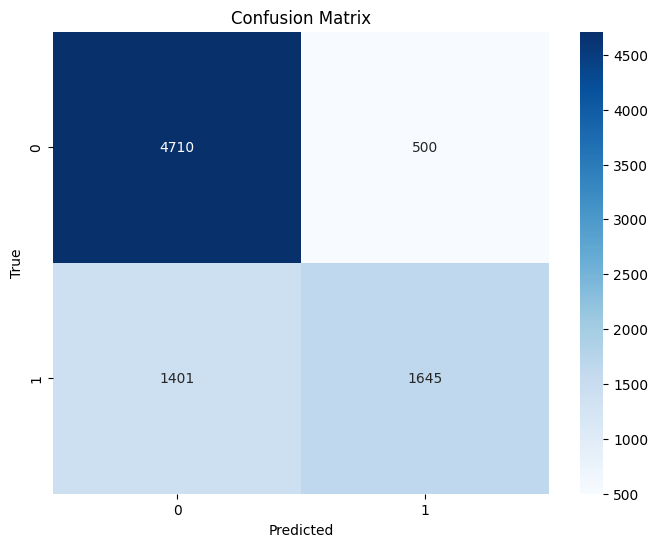

In [ ]:
print("Classification Report:")
pred = gain_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## NOISE APP model

#### Noise APP Hyperparameter Tuning

In [ ]:
noise_GRUmodel = build_model(num_classes=2,units=70, learning_rate=0.001, momentum=0.99, optimizer='adam')
noise_GRUmodel.fit(noiseX_train, noiseY_train,batch_size=30, epochs=80)
joblib.dump(noise_GRUmodel, '/content/drive/MyDrive/models/noiseGRU_50ct_datamodel.pkl')

Model compiled!
Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_44 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_45 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_46 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_47 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_11 (Ba  (None, 70)                280       
 tchNormalization)                                               
                                                                 
 dense_11 (Dense)            (None, 2)                 142       
                                     

['/content/drive/MyDrive/models/noiseGRU_50ct_datamodel.pkl']

#### Single Fault Detections Tests

##### Noise Data

Classification Report:
259/259 [==============================] - 5s 16ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5684
           1       0.98      0.98      0.98      2581

    accuracy                           0.99      8265
   macro avg       0.99      0.99      0.99      8265
weighted avg       0.99      0.99      0.99      8265

Confusion Matrix:


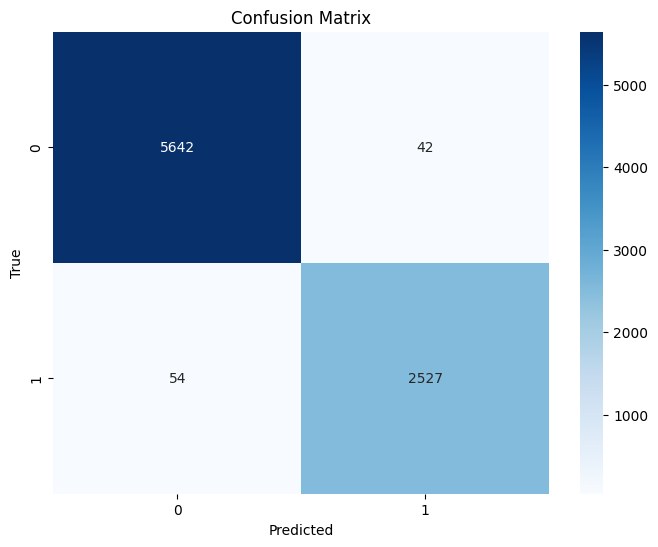

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
67/67 [==============================] - 3s 36ms/step
              precision    recall  f1-score   support

           0       0.91      0.50      0.64      2017
           1       0.02      0.14      0.03       116

    accuracy                           0.48      2133
   macro avg       0.46      0.32      0.34      2133
weighted avg       0.86      0.48      0.61      2133

Confusion Matrix:


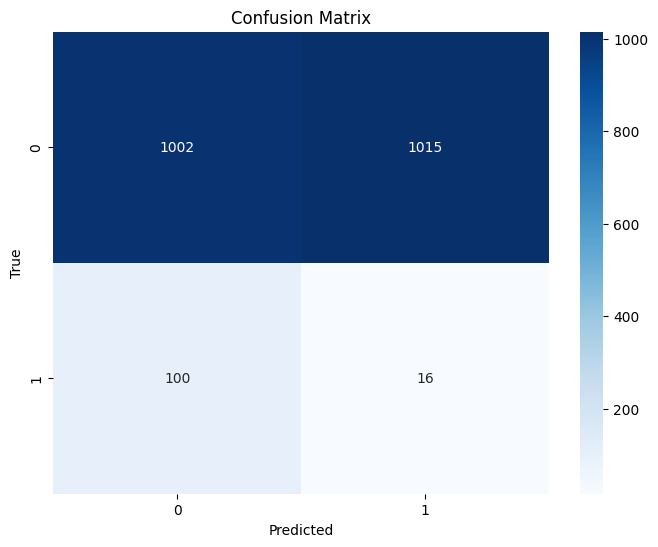

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

#### Gain Data

Classification Report:
260/260 [==============================] - 7s 27ms/step
              precision    recall  f1-score   support

           0       0.57      0.77      0.66      5048
           1       0.24      0.12      0.16      3244

    accuracy                           0.51      8292
   macro avg       0.41      0.44      0.41      8292
weighted avg       0.44      0.51      0.46      8292

Confusion Matrix:


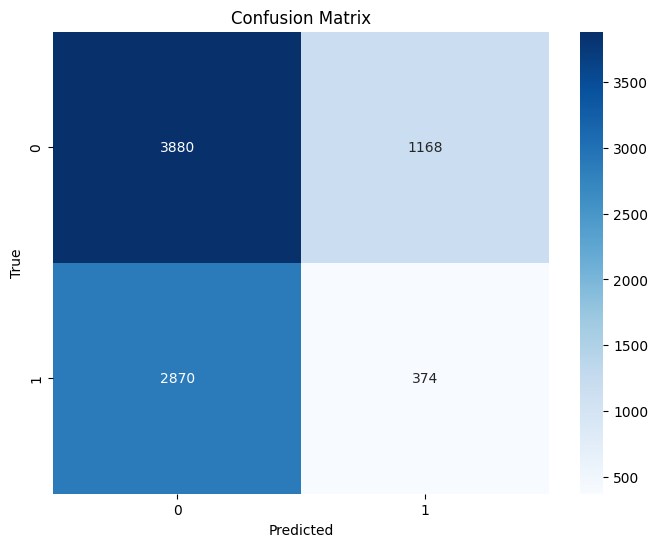

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Packet Loss Data

Classification Report:
258/258 [==============================] - 4s 15ms/step
              precision    recall  f1-score   support

           0       0.73      0.90      0.81      5210
           1       0.72      0.42      0.53      3046

    accuracy                           0.73      8256
   macro avg       0.72      0.66      0.67      8256
weighted avg       0.72      0.73      0.70      8256

Confusion Matrix:


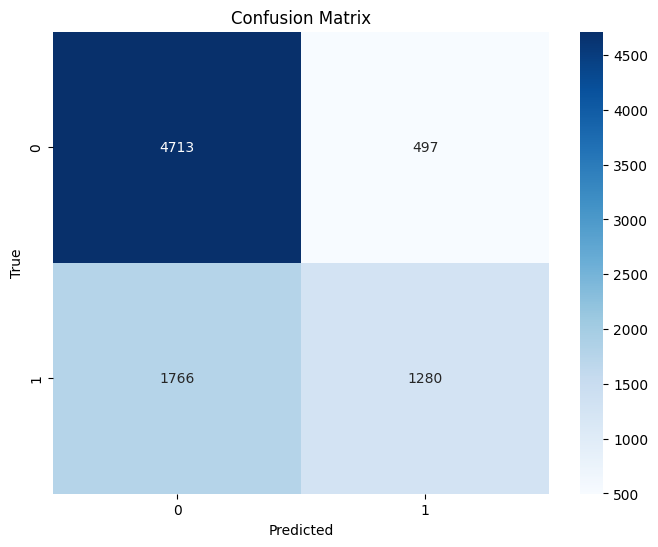

In [ ]:
print("Classification Report:")
pred = noise_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## PACKETLOSS APP model

#### PacketLossAPP-GRU Hyperparameter Tuning

In [ ]:
packetLoss_GRUmodel = build_model(num_classes=2, units=70, learning_rate=0.001, momentum=0.99, optimizer='adam')
packetLoss_GRUmodel.fit(packetLossX_train, packetLossY_train,batch_size=30, epochs=50)
joblib.dump(packetLoss_GRUmodel, '/content/drive/MyDrive/models/packetLoss_50pct_dataGRU_model.pkl')

Model compiled!
Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_48 (GRU)                (None, 20, 70)            16590     
                                                                 
 gru_49 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_50 (GRU)                (None, 20, 70)            29820     
                                                                 
 gru_51 (GRU)                (None, 70)                29820     
                                                                 
 batch_normalization_12 (Ba  (None, 70)                280       
 tchNormalization)                                               
                                                                 
 dense_12 (Dense)            (None, 2)                 142       
                                     

['/content/drive/MyDrive/models/packetLoss_50pct_dataGRU_model.pkl']

##### Single Fault Detection Tests

##### Packet Loss Data

Classification Report:
258/258 [==============================] - 11s 35ms/step
              precision    recall  f1-score   support

           0       0.87      0.99      0.93      5210
           1       0.98      0.74      0.85      3046

    accuracy                           0.90      8256
   macro avg       0.93      0.87      0.89      8256
weighted avg       0.91      0.90      0.90      8256

Confusion Matrix:


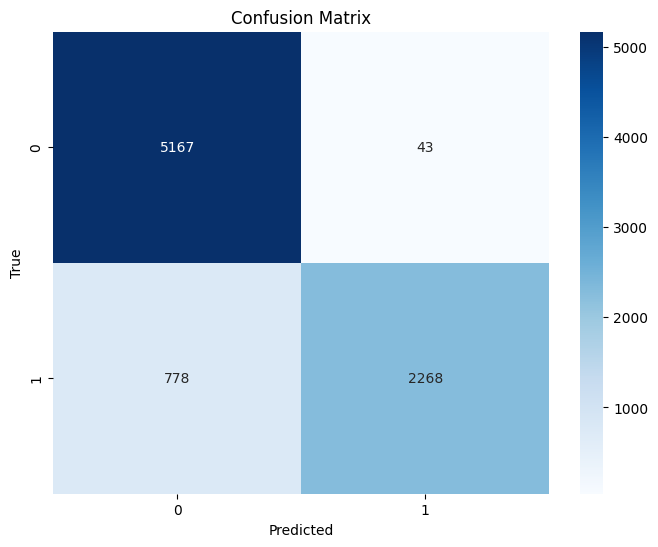

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(packetLossX_test)
y_true, pred= single_fault_voter(packetLossY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Gain Data

Classification Report:
260/260 [==============================] - 9s 27ms/step
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      5048
           1       0.93      0.62      0.75      3244

    accuracy                           0.84      8292
   macro avg       0.87      0.80      0.81      8292
weighted avg       0.85      0.84      0.83      8292

Confusion Matrix:


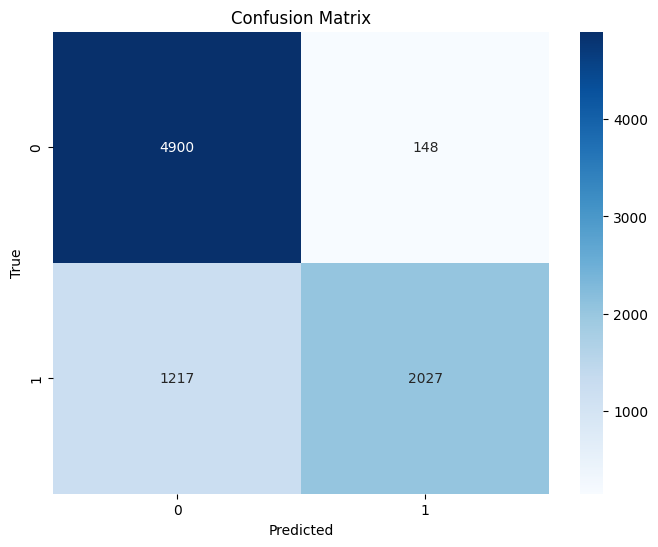

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(gainX_test)
y_true, pred= single_fault_voter(gainY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Noise Data

Classification Report:
259/259 [==============================] - 5s 21ms/step
              precision    recall  f1-score   support

           0       0.84      0.58      0.69      5684
           1       0.45      0.76      0.57      2581

    accuracy                           0.64      8265
   macro avg       0.65      0.67      0.63      8265
weighted avg       0.72      0.64      0.65      8265

Confusion Matrix:


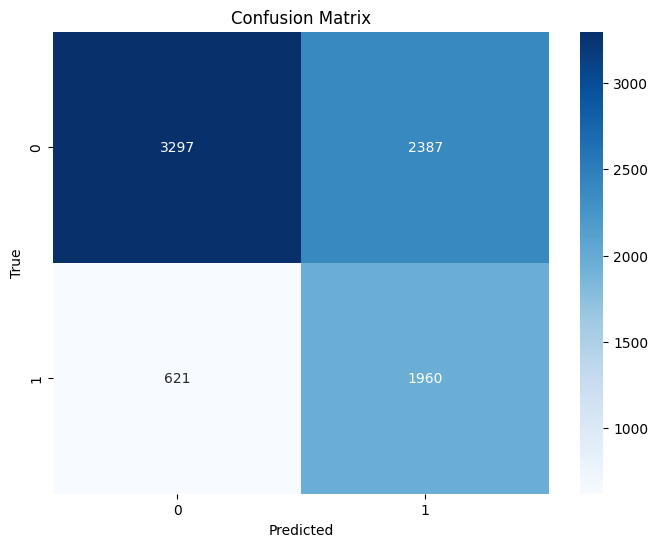

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(noiseX_test)
y_true, pred= single_fault_voter(noiseY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

##### Delay Data

Classification Report:
67/67 [==============================] - 1s 16ms/step
              precision    recall  f1-score   support

           0       0.96      0.84      0.90      2017
           1       0.10      0.32      0.16       116

    accuracy                           0.81      2133
   macro avg       0.53      0.58      0.53      2133
weighted avg       0.91      0.81      0.86      2133

Confusion Matrix:


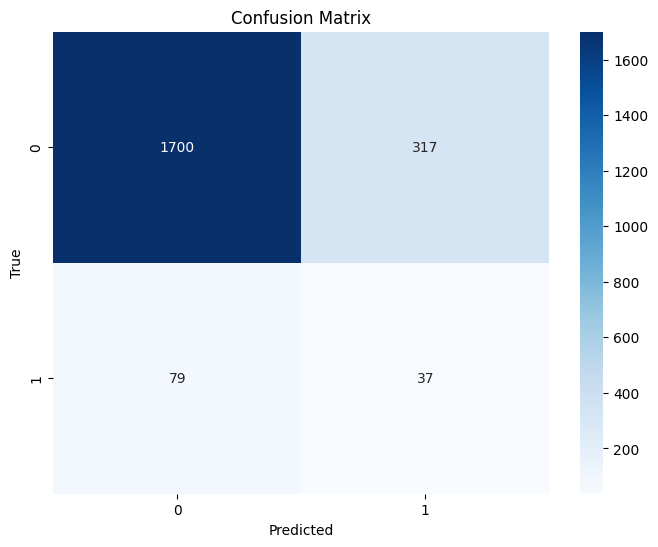

In [ ]:
print("Classification Report:")
pred = packetLoss_GRUmodel.predict(delayX_test)
y_true, pred= single_fault_voter(delayY_test, pred)
report = generate_classificationReport(y_true, pred)
print(report)
print("Confusion Matrix:")
plot_confusion_matrix(y_true, pred, classes=[0,1], title='Confusion Matrix')

## CONCURRENT FAULTS DETECTION

In [ ]:
delay_GRUmodel = joblib.load('/content/drive/MyDrive/models/delayGRU_model.pkl')
gain_GRUmodel = joblib.load('/content/drive/MyDrive/models/gainGRU_model.pkl')
noise_GRUmodel = joblib.load('/content/drive/MyDrive/models/noiseGRU_model.pkl')
packetLoss_GRUmodel = joblib.load('/content/drive/MyDrive/models/packetLosGRU_model.pkl')


In [ ]:
models_dict = {
    "delay_model": delay_GRUmodel,
    "gain_model": gain_GRUmodel,
    "noise_model": noise_GRUmodel,
    "packetLos_model": packetLoss_GRUmodel,
}
data_dict = {
    "F1": [delayX_test, delayY_test],
    "F2": [gainX_test, gainY_test],
    "F3": [noiseX_test, noiseY_test],
    "F4": [packetLossX_test, packetLossY_test],
}
concurent_faultsVoter(models_dict, data_dict)

258/258 [==============================] - 5s 21ms/step


{'F1': {'delay_model': 0.9756211908110642,
  'gain_model': 0.5475855602437881,
  'noise_model': 0.4772620721987811,
  'packetLos_model': 0.8143459915611815},
 'F2': {'delay_model': 0.7366136034732272,
  'gain_model': 0.970935841775205,
  'noise_model': 0.5130246020260492,
  'packetLos_model': 0.835383502170767},
 'F3': {'delay_model': 0.4377495462794918,
  'gain_model': 0.7725347852389595,
  'noise_model': 0.9883847549909256,
  'packetLos_model': 0.6360556563823352},
 'F4': {'delay_model': 0.581031976744186,
  'gain_model': 0.7697432170542635,
  'noise_model': 0.7258963178294574,
  'packetLos_model': 0.9005571705426356}}